# Seção 1 - Configuração Geral e Carregamento das Bases

In [ ]:
# ==============================================================================
# NOTEBOOK 05
# INTELIGÊNCIA ANALÍTICA DO PAS/UnB
#
# ==============================================================================

# ==============================================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ==============================================================================

from pathlib import Path

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")


# ==============================================================================
# 2. CONFIGURAÇÕES GERAIS
# ==============================================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

sns.set_palette("deep")


# ==============================================================================
# 3. DIRETÓRIOS
# ==============================================================================


def resolver_base() -> Path:
    """Resolve o diretório raiz do projeto em qualquer ambiente."""
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "tsv").exists() and (candidate / "catalogos").exists():
            return candidate

    return cwd


PASTA_BASE = resolver_base()
PASTA_DADOS = PASTA_BASE / "estatisticas"

ARQUIVO_PREDICOES = PASTA_DADOS / "predicoes.csv"
ARQUIVO_BASE = PASTA_DADOS / "base_analitica.csv"
ARQUIVO_ESTUDANTE = PASTA_DADOS / "planilha_estudante.csv"


# ==============================================================================
# 4. VALIDAÇÃO DOS ARQUIVOS
# ==============================================================================

arquivos = {
    "predicoes.csv": ARQUIVO_PREDICOES,
    "base_analitica.csv": ARQUIVO_BASE,
    "planilha_estudante.csv": ARQUIVO_ESTUDANTE,
}

print("=" * 80)
print("VALIDAÇÃO DOS ARQUIVOS")
print("=" * 80)

for nome, caminho in arquivos.items():

    if caminho.exists():
        print(f"[OK] {nome}")

    else:
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")


# ==============================================================================
# 5. CARREGAMENTO DAS BASES
# ==============================================================================

print("\nCarregando bases...")

df_predicoes = pd.read_csv(ARQUIVO_PREDICOES)

df_base = pd.read_csv(ARQUIVO_BASE)

df_estudante = pd.read_csv(ARQUIVO_ESTUDANTE)

print("Bases carregadas com sucesso.")


# ==============================================================================
# 6. FUNÇÃO DE DIAGNÓSTICO
# ==============================================================================

def diagnostico_dataframe(df: pd.DataFrame, nome: str) -> None:
    """
    Exibe um diagnóstico resumido de um DataFrame.

    Parâmetros
    ----------
    df : pandas.DataFrame
        Base analisada.

    nome : str
        Nome utilizado na impressão.
    """

    print("\n" + "=" * 80)
    print(nome.upper())
    print("=" * 80)

    print(f"Linhas.....................: {len(df):,}")

    print(f"Colunas....................: {len(df.columns)}")

    memoria = df.memory_usage(deep=True).sum() / 1024**2

    print(f"Memória....................: {memoria:.2f} MB")

    print(f"Valores ausentes...........: {df.isna().sum().sum():,}")

    print("\nTipos de dados:")

    display(df.dtypes.value_counts().rename("Quantidade"))

    print("\nPrimeiras linhas:")

    display(df.head())


# ==============================================================================
# 7. DIAGNÓSTICO DAS BASES
# ==============================================================================

diagnostico_dataframe(
    df_predicoes,
    "Predições"
)

diagnostico_dataframe(
    df_base,
    "Base Analítica"
)

diagnostico_dataframe(
    df_estudante,
    "Planilha do Estudante"
)


# ==============================================================================
# 8. RESUMO FINAL
# ==============================================================================

print("\n")
print("=" * 80)
print("RESUMO DAS BASES")
print("=" * 80)

resumo = pd.DataFrame({

    "Base": [
        "Predições",
        "Base Analítica",
        "Planilha Estudante"
    ],

    "Linhas": [
        len(df_predicoes),
        len(df_base),
        len(df_estudante)
    ],

    "Colunas": [
        df_predicoes.shape[1],
        df_base.shape[1],
        df_estudante.shape[1]
    ]

})

display(resumo)

print("\nInfraestrutura analítica inicializada com sucesso.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VALIDAÇÃO DOS ARQUIVOS
[OK] predicoes.csv
[OK] base_analitica.csv
[OK] planilha_estudante.csv

Carregando bases...
Bases carregadas com sucesso.

PREDIÇÕES
Linhas.....................: 765
Colunas....................: 58
Memória....................: 0.64 MB
Valores ausentes...........: 5,238

Tipos de dados:


,Quantidade
float64,47
int64,6
object,5



Primeiras linhas:


,id_oferta,id_oferta_num,curso,campus,turno,modalidade,observacoes_min,observacoes_max,primeira_nota_min,ultima_nota_min,primeira_nota_max,ultima_nota_max,media_historica_min,mediana_historica_min,minimo_historico_min,maximo_historico_min,amplitude_historica_min,desvio_historico_min,coef_var_min,consistencia_min,mudancas_min,volatilidade_min,media_historica_max,mediana_historica_max,minimo_historico_max,maximo_historico_max,amplitude_historica_max,desvio_historico_max,coef_var_max,consistencia_max,mudancas_max,volatilidade_max,persistencia_min,r2_persistencia_min,regressao_linear_min,r2_regressao_linear_min,regressao_ponderada_min,r2_regressao_ponderada_min,media_movel_min,r2_media_movel_min,persistencia_max,r2_persistencia_max,regressao_linear_max,r2_regressao_linear_max,regressao_ponderada_max,r2_regressao_ponderada_max,media_movel_max,r2_media_movel_max,ensemble_min,ensemble_mediana_min,ensemble_desvio_min,ensemble_amplitude_min,ensemble_n_modelos_min,ensemble_max,ensemble_mediana_max,ensemble_desvio_max,ensemble_amplitude_max,ensemble_n_modelos_max
0,Administração (Bacharelado) | Darcy Ribeiro | Diurno | AC | EP=False | R=NA ...,1,Administração (Bacharelado),Darcy Ribeiro,Diurno,AC,6,6,-5.813,38.131,69.035,99.156,26.868,37.418,-5.813,46.485,52.298,23.412,87.136,80.000,2.0,35.681,82.398,96.546,12.807,120.300,107.493,37.802,45.877,60.000,2,65.453,38.131,NaN,37.962,0.064,28.688,-0.031,29.510,NaN,99.156,NaN,64.876,0.061,62.418,0.059,78.226,NaN,33.573,33.736,5.177,9.443,4,76.169,71.551,16.825,36.738,4
1,Administração (Bacharelado) | Darcy Ribeiro | Noturno | AC | EP=False | R=NA...,2,Administração (Bacharelado),Darcy Ribeiro,Noturno,AC,6,6,-98.900,-7.050,38.986,44.901,-38.006,-16.271,-98.900,-2.777,96.123,42.970,-113.060,60.000,2.0,68.732,40.601,47.522,-40.646,98.221,138.867,45.085,111.043,60.000,4,73.686,-7.050,NaN,-17.479,0.065,-29.290,0.019,-33.119,NaN,44.901,NaN,2.085,0.209,0.305,0.208,31.431,NaN,-21.734,-23.384,11.838,26.069,4,19.680,16.758,22.054,44.596,4
2,Administração (Bacharelado) | Darcy Ribeiro | Diurno | CN | EP=False | R=NA ...,3,Administração (Bacharelado),Darcy Ribeiro,Diurno,CN,6,6,-40.808,-12.580,3.022,6.842,-28.120,-26.694,-54.707,-4.981,49.726,22.874,-81.344,60.000,4.0,48.142,-7.373,1.368,-49.856,44.699,94.555,36.280,-492.069,60.000,3,76.162,-12.580,NaN,-24.194,0.008,-23.703,0.008,-27.185,NaN,6.842,NaN,-10.520,0.002,-5.991,-0.007,-8.122,NaN,-21.916,-23.949,6.411,14.605,4,-4.448,-7.057,7.751,17.362,4
3,Administração (Bacharelado) | Darcy Ribeiro | Noturno | CN | EP=False | R=NA...,4,Administração (Bacharelado),Darcy Ribeiro,Noturno,CN,5,5,-3.806,-54.846,1.212,-53.830,-23.060,-6.548,-54.846,-1.176,53.670,26.464,-114.765,50.000,3.0,43.831,-6.654,1.212,-53.830,19.031,72.861,27.610,-414.944,50.000,1,29.730,-54.846,NaN,-58.810,0.468,-59.141,0.467,-30.223,NaN,-53.830,NaN,-48.142,0.579,-59.904,0.455,-14.281,NaN,-50.755,-56.828,13.826,28.918,4,-44.039,-50.986,20.412,45.623,4
4,Administração (Bacharelado) | Darcy Ribeiro | Diurno | EP_R1_NPPI | EP=True ...,5,Administração (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPI,4,4,-90.624,-59.221,-3.524,-21.197,-51.749,-50.495,-90.624,-15.383,75.241,31.566,-60.997,66.667,1.0,56.273,-2.144,-1.766,-21.197,16.153,37.350,15.322,-714.546,66.667,1,27.969,-59.221,NaN,-34.793,0.077,-53.332,-0.096,-48.358,NaN,-21.197,NaN,-11.358,0.096,-19.532,-0.046,-3.987,NaN,-48.926,-50.845,10.416,24.428,4,-14.019,-15.445,7.950,17.210,4



BASE ANALÍTICA
Linhas.....................: 765
Colunas....................: 62
Memória....................: 0.70 MB
Valores ausentes...........: 1,105

Tipos de dados:


...


Primeiras linhas:


,Curso,Campus,Turno,Modalidade,Triênios,Primeira Nota,Última Nota,Média Histórica,Mediana Histórica,Mínimo Histórico,Máximo Histórico,Previsão,Δ Média,Δ Última,Índice de Estabilidade,Estabilidade,CV (%),Desvio,Amplitude,Volatilidade,Mudanças
0,Administração (Bacharelado),Darcy Ribeiro,Diurno,AC,6,-5.81,38.13,26.87,37.42,-5.81,46.48,33.57,6.70,-4.56,36.22,Baixa,87.14,23.41,52.30,35.68,2.0
1,Administração (Bacharelado),Darcy Ribeiro,Diurno,CN,6,-40.81,-12.58,-28.12,-26.69,-54.71,-4.98,-21.92,6.20,-9.34,45.41,Moderada,-81.34,22.87,49.73,48.14,4.0
2,Administração (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPI,4,-90.62,-59.22,-51.75,-50.50,-90.62,-15.38,-48.93,2.82,10.30,41.21,Moderada,-61.00,31.57,75.24,56.27,1.0
3,Administração (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPIQ,1,-67.83,-67.83,-67.83,-67.83,-67.83,-67.83,-67.83,0.00,0.00,57.25,Moderada,0.00,0.00,0.00,0.00,0.0
4,Administração (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_PPI,4,-32.29,-53.79,-42.77,-42.49,-53.79,-32.29,-55.59,-12.82,-1.80,61.91,Alta,-22.02,9.42,21.50,1.15,0.0




RESUMO DAS BASES


,Base,Linhas,Colunas
0,Predições,765,58
1,Base Analítica,765,62
2,Planilha Estudante,765,21



Infraestrutura analítica inicializada com sucesso.


# Seção 2 - Preparação da Base Analítica

In [18]:
# ==============================================================================
# 9. PREPARAÇÃO DA BASE ANALÍTICA
# ==============================================================================

print("=" * 80)
print("PREPARAÇÃO DA BASE ANALÍTICA")
print("=" * 80)

# ------------------------------------------------------------------------------
# Cópias de trabalho
# ------------------------------------------------------------------------------

predicoes = df_predicoes.copy()

base = df_base.copy()

estudante = df_estudante.copy()

# ------------------------------------------------------------------------------
# Organização das colunas
# ------------------------------------------------------------------------------

colunas_numericas = predicoes.select_dtypes(
    include=["number"]
).columns.tolist()

colunas_categoricas = predicoes.select_dtypes(
    exclude=["number"]
).columns.tolist()

# ------------------------------------------------------------------------------
# Valores únicos
# ------------------------------------------------------------------------------

modalidades = sorted(
    predicoes["modalidade"].dropna().unique().tolist()
)

campi = sorted(
    predicoes["campus"].dropna().unique().tolist()
)

turnos = sorted(
    predicoes["turno"].dropna().unique().tolist()
)

cursos = sorted(
    predicoes["curso"].dropna().unique().tolist()
)

# ------------------------------------------------------------------------------
# Base principal da Ampla Concorrência
# ------------------------------------------------------------------------------

predicoes_ac = (
    predicoes
    .query("modalidade == 'AC'")
    .copy()
)

# ------------------------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------------------------

def selecionar_modalidade(df, modalidade):
    """
    Retorna apenas os registros da modalidade informada.
    """
    return df.loc[df["modalidade"] == modalidade].copy()


def selecionar_campus(df, campus):
    """
    Retorna apenas um campus.
    """
    return df.loc[df["campus"] == campus].copy()


def selecionar_turno(df, turno):
    """
    Retorna apenas um turno.
    """
    return df.loc[df["turno"] == turno].copy()


def selecionar_curso(df, curso):
    """
    Retorna apenas um curso.
    """
    return df.loc[df["curso"] == curso].copy()

# ------------------------------------------------------------------------------
# Resumo estrutural
# ------------------------------------------------------------------------------

print(f"\nCursos.....................: {len(cursos)}")
print(f"Campi......................: {len(campi)}")
print(f"Turnos.....................: {len(turnos)}")
print(f"Modalidades............... : {len(modalidades)}")

print(f"\nColunas numéricas..........: {len(colunas_numericas)}")
print(f"Colunas categóricas........: {len(colunas_categoricas)}")

print(f"\nRegistros completos........: {len(predicoes):,}")
print(f"Registros AC...............: {len(predicoes_ac):,}")

# ------------------------------------------------------------------------------
# Listagem das categorias
# ------------------------------------------------------------------------------

print("\nModalidades:")
display(pd.DataFrame({"Modalidade": modalidades}))

print("\nCampi:")
display(pd.DataFrame({"Campus": campi}))

print("\nTurnos:")
display(pd.DataFrame({"Turno": turnos}))

PREPARAÇÃO DA BASE ANALÍTICA

Cursos.....................: 90
Campi......................: 4
Turnos.....................: 2
Modalidades............... : 17

Colunas numéricas..........: 53
Colunas categóricas........: 5

Registros completos........: 765
Registros AC...............: 105

Modalidades:


,Modalidade
0,AC
1,CN
2,EP_R1_NPPI
3,EP_R1_NPPIQ
4,EP_R1_NPPIQ_PCD
5,EP_R1_NPPI_PCD
6,EP_R1_PPI
7,EP_R1_PPIQ
8,EP_R1_PPI_PCD
9,EP_R2_NPPI



Campi:


,Campus
0,Ceilândia
1,Darcy Ribeiro
2,Gama
3,Planaltina



Turnos:


,Turno
0,Diurno
1,Noturno


# Seção 3 - Panorama Geral da Base Analítica

PAINEL EXECUTIVO DA BASE


,Indicador,Valor
0,Total de ofertas,765
1,Cursos distintos,90
2,Campi,4
3,Turnos,2
4,Modalidades,17


,modalidade,Ofertas
0,AC,105
9,EP_R2_NPPI,99
13,EP_R2_PPI,95
1,CN,91
2,EP_R1_NPPI,87
6,EP_R1_PPI,85
10,EP_R2_NPPIQ,67
14,EP_R2_PPIQ,53
3,EP_R1_NPPIQ,41
11,EP_R2_NPPIQ_PCD,15


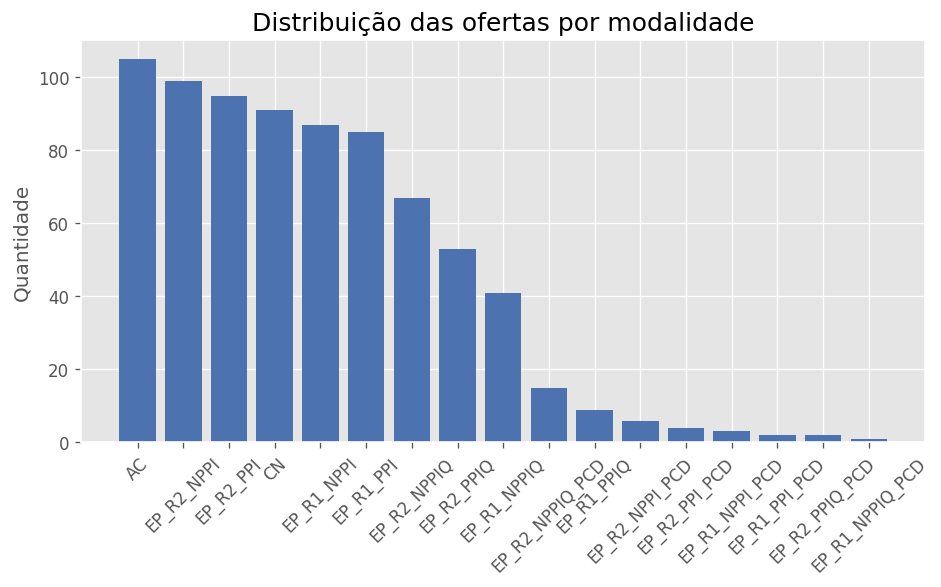

,campus,Ofertas
1,Darcy Ribeiro,689
0,Ceilândia,54
3,Planaltina,12
2,Gama,10


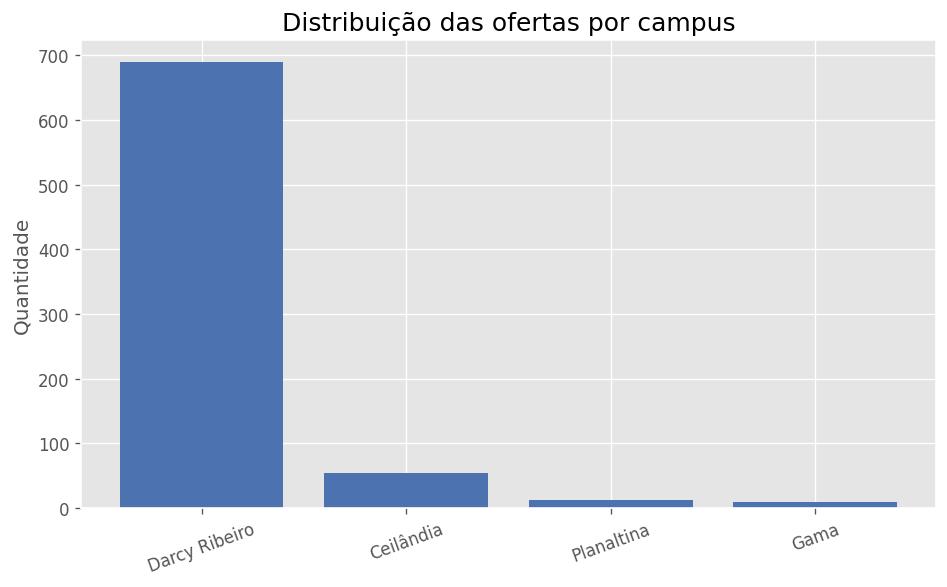

,turno,Ofertas
0,Diurno,587
1,Noturno,178


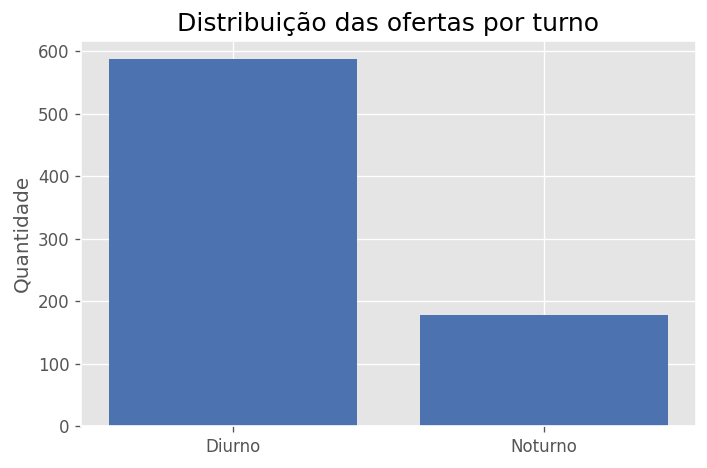

,Modelo,Valores disponíveis
0,persistencia_min,764
1,regressao_linear_min,495
2,regressao_ponderada_min,495
3,media_movel_min,764
4,ensemble_min,764



Painel executivo concluído.


In [19]:
# ==============================================================================
# 10. PAINEL EXECUTIVO DA BASE DE PREDIÇÕES
# ==============================================================================

print("=" * 80)
print("PAINEL EXECUTIVO DA BASE")
print("=" * 80)

# ==============================================================================
# INDICADORES GERAIS
# ==============================================================================

painel = pd.DataFrame({

    "Indicador": [

        "Total de ofertas",
        "Cursos distintos",
        "Campi",
        "Turnos",
        "Modalidades"

    ],

    "Valor": [

        predicoes["id_oferta"].nunique(),
        predicoes["curso"].nunique(),
        predicoes["campus"].nunique(),
        predicoes["turno"].nunique(),
        predicoes["modalidade"].nunique()

    ]

})

display(painel)

# ==============================================================================
# DISTRIBUIÇÃO POR MODALIDADE
# ==============================================================================

modalidades = (
    predicoes
    .groupby("modalidade")
    .size()
    .reset_index(name="Ofertas")
    .sort_values("Ofertas", ascending=False)
)

display(modalidades)

plt.figure(figsize=(8,5))

plt.bar(
    modalidades["modalidade"],
    modalidades["Ofertas"]
)

plt.title("Distribuição das ofertas por modalidade")

plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==============================================================================
# DISTRIBUIÇÃO POR CAMPUS
# ==============================================================================

campi = (
    predicoes
    .groupby("campus")
    .size()
    .reset_index(name="Ofertas")
    .sort_values("Ofertas", ascending=False)
)

display(campi)

plt.figure(figsize=(8,5))

plt.bar(
    campi["campus"],
    campi["Ofertas"]
)

plt.title("Distribuição das ofertas por campus")

plt.ylabel("Quantidade")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# ==============================================================================
# DISTRIBUIÇÃO POR TURNO
# ==============================================================================

turnos = (
    predicoes
    .groupby("turno")
    .size()
    .reset_index(name="Ofertas")
    .sort_values("Ofertas", ascending=False)
)

display(turnos)

plt.figure(figsize=(6,4))

plt.bar(
    turnos["turno"],
    turnos["Ofertas"]
)

plt.title("Distribuição das ofertas por turno")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# COBERTURA DOS MODELOS
# ==============================================================================

modelos = [

    "persistencia_min",
    "regressao_linear_min",
    "regressao_ponderada_min",
    "media_movel_min",
    "ensemble_min"

]

cobertura = pd.DataFrame({

    "Modelo": modelos,

    "Valores disponíveis": [

        predicoes[c].notna().sum()

        for c in modelos

    ]

})

display(cobertura)

print("\nPainel executivo concluído.")

# Seção 4 - Panorama Estatístico da Ampla Concorrência (AC)

PANORAMA ESTATÍSTICO - AMPLA CONCORRÊNCIA
Registros analisados: 105


,count,mean,std,min,25%,50%,75%,max
media_historica_min,105.0,-7.431238,55.199825,-86.439,-51.341,-19.674,27.598,171.083
mediana_historica_min,105.0,-2.801133,58.056404,-89.917,-56.057,-13.502,49.195,166.750
minimo_historico_min,105.0,-41.533610,57.224522,-105.030,-82.398,-64.096,-13.502,162.424
maximo_historico_min,105.0,20.417981,57.804692,-71.509,-30.090,11.533,61.623,183.500
amplitude_historica_min,105.0,61.951590,38.694184,0.000,36.969,52.174,80.875,190.354
desvio_historico_min,105.0,25.741267,16.271251,0.000,14.716,20.965,35.264,83.046
coef_var_min,105.0,-5.727286,392.753776,-1002.481,-80.304,-21.442,24.469,3541.599
media_historica_max,105.0,58.540495,49.292971,-41.871,27.989,51.117,95.650,194.988
mediana_historica_max,105.0,62.304324,53.250838,-52.043,22.858,54.376,104.096,190.742
minimo_historico_max,105.0,13.197381,49.127692,-85.500,-17.112,12.807,38.883,173.057


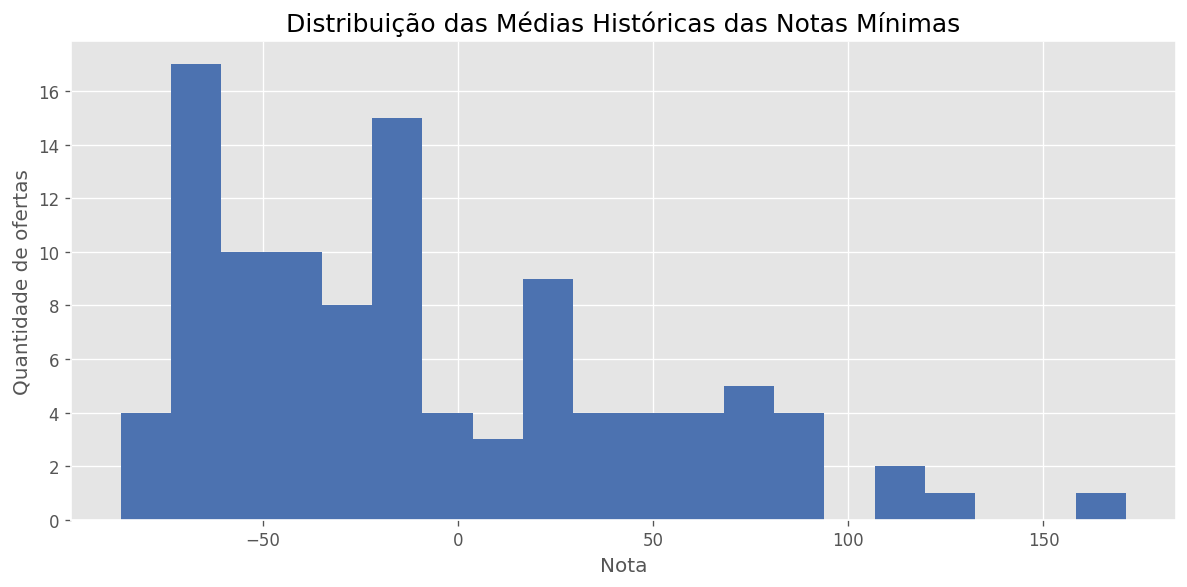

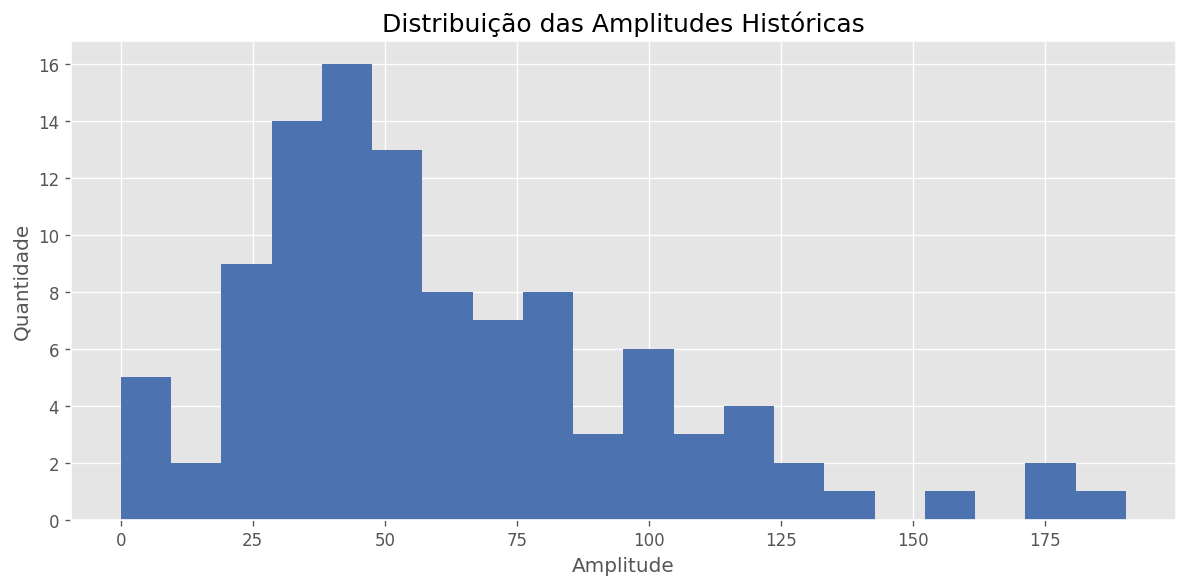

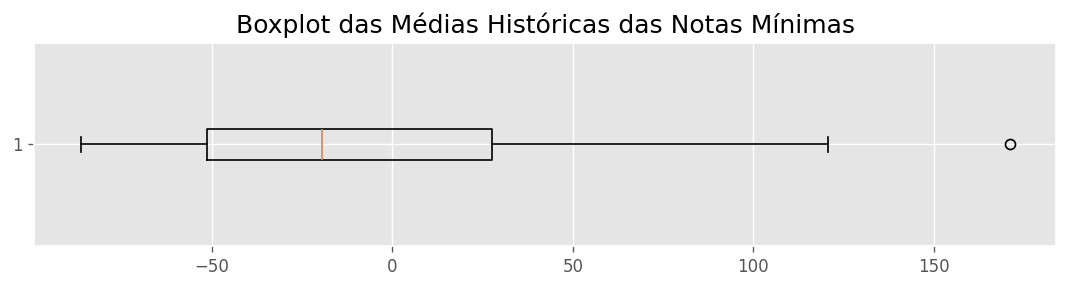

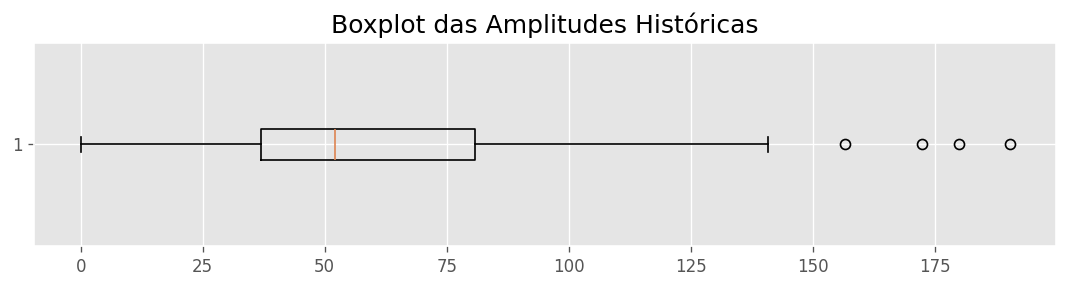


TOP 10 MAIORES MÉDIAS HISTÓRICAS



,curso,campus,turno,media_historica_min
604,Medicina (Bacharelado),Darcy Ribeiro,Diurno,171.083
126,Ciência da Computação (Bacharelado),Darcy Ribeiro,Diurno,120.698
226,Direito (Bacharelado),Darcy Ribeiro,Diurno,119.530
343,Engenharia de Computação (Bacharelado),Darcy Ribeiro,Diurno,108.165
677,Psicologia (Bacharelado / Licenciatura / Psicólogo),Darcy Ribeiro,Diurno,91.697
709,Relações Internacionais (Bacharelado),Darcy Ribeiro,Diurno,88.904
227,Direito (Bacharelado),Darcy Ribeiro,Noturno,83.782
522,Jornalismo (Bacharelado),Darcy Ribeiro,Diurno,83.043
25,Arquitetura e Urbanismo (Bacharelado),Darcy Ribeiro,Diurno,79.586
161,Ciências Econômicas (Bacharelado),Darcy Ribeiro,Diurno,79.392



TOP 10 MENORES MÉDIAS HISTÓRICAS



,curso,campus,turno,media_historica_min
759,Turismo (Bacharelado),Darcy Ribeiro,Diurno,-86.439
170,Ciências Naturais (Licenciatura),Planaltina,Diurno,-79.819
497,Gestão do Agronegócio (Bacharelado),Planaltina,Diurno,-78.812
719,Saúde Coletiva (Bacharelado),Ceilândia,Diurno,-78.473
139,Ciências Ambientais (Bacharelado),Darcy Ribeiro,Noturno,-70.227
531,Letras - Espanhol (Licenciatura),Darcy Ribeiro,Noturno,-70.106
482,Gestão de Agronegócio (Bacharelado),Darcy Ribeiro,Noturno,-69.012
59,Artes Cênicas (Literatura),Darcy Ribeiro,Noturno,-68.863
473,Geologia (Bacharelado),Darcy Ribeiro,Diurno,-67.950
417,Filosofia (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-67.838



Panorama estatístico concluído.


In [20]:
# ==============================================================================
# 11. PANORAMA ESTATÍSTICO DA AMPLA CONCORRÊNCIA
# ==============================================================================

print("=" * 80)
print("PANORAMA ESTATÍSTICO - AMPLA CONCORRÊNCIA")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base da AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

print(f"Registros analisados: {len(ac):,}")

# ==============================================================================
# ESTATÍSTICAS DESCRITIVAS
# ==============================================================================

variaveis = [

    "media_historica_min",
    "mediana_historica_min",
    "minimo_historico_min",
    "maximo_historico_min",
    "amplitude_historica_min",
    "desvio_historico_min",
    "coef_var_min",

    "media_historica_max",
    "mediana_historica_max",
    "minimo_historico_max",
    "maximo_historico_max",
    "amplitude_historica_max",
    "desvio_historico_max",
    "coef_var_max"

]

estatisticas = (
    ac[variaveis]
    .describe()
    .T
)

display(estatisticas)

# ==============================================================================
# HISTOGRAMA DAS MÉDIAS HISTÓRICAS
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["media_historica_min"],
    bins=20
)

plt.title("Distribuição das Médias Históricas das Notas Mínimas")

plt.xlabel("Nota")

plt.ylabel("Quantidade de ofertas")

plt.tight_layout()

plt.show()

# ==============================================================================
# HISTOGRAMA DAS AMPLITUDES
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["amplitude_historica_min"],
    bins=20
)

plt.title("Distribuição das Amplitudes Históricas")

plt.xlabel("Amplitude")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# BOXPLOT DAS NOTAS MÍNIMAS
# ==============================================================================

plt.figure(figsize=(9,2.5))

plt.boxplot(
    ac["media_historica_min"],
    vert=False
)

plt.title("Boxplot das Médias Históricas das Notas Mínimas")

plt.tight_layout()

plt.show()

# ==============================================================================
# BOXPLOT DAS AMPLITUDES
# ==============================================================================

plt.figure(figsize=(9,2.5))

plt.boxplot(
    ac["amplitude_historica_min"],
    vert=False
)

plt.title("Boxplot das Amplitudes Históricas")

plt.tight_layout()

plt.show()

# ==============================================================================
# CURSOS COM MAIORES MÉDIAS HISTÓRICAS
# ==============================================================================

top10 = (

    ac

    .sort_values(
        "media_historica_min",
        ascending=False
    )

    [[
        "curso",
        "campus",
        "turno",
        "media_historica_min"
    ]]

    .head(10)

)

print("\nTOP 10 MAIORES MÉDIAS HISTÓRICAS\n")

display(top10)

# ==============================================================================
# CURSOS COM MENORES MÉDIAS HISTÓRICAS
# ==============================================================================

bottom10 = (

    ac

    .sort_values(
        "media_historica_min"
    )

    [[
        "curso",
        "campus",
        "turno",
        "media_historica_min"
    ]]

    .head(10)

)

print("\nTOP 10 MENORES MÉDIAS HISTÓRICAS\n")

display(bottom10)

print("\nPanorama estatístico concluído.")

# Seção 5 - Evolução Histórica das Notas de Corte

EVOLUÇÃO HISTÓRICA DAS NOTAS DE CORTE


,variacao_absoluta,variacao_percentual
count,105.000000,105.000000
mean,35.702152,-24.330664
std,43.452142,204.574194
min,-47.738000,-766.279179
25%,0.000000,-97.935397
50%,34.405000,-15.641885
75%,59.642000,37.317578
max,185.351000,962.488809



CURSOS COM MAIOR CRESCIMENTO



,curso,campus,turno,primeira_nota_min,ultima_nota_min,variacao_absoluta
326,Engenharia Mecânica (Bacharelado),Darcy Ribeiro,Diurno,-102.234,83.117,185.351
371,Engenharias (FGA),Gama,Diurno,-101.981,61.705,163.686
302,Engenharia Elétrica (Bacharelado),Darcy Ribeiro,Diurno,-54.460,97.075,151.535
317,Engenharia Mecatrônica (Bacharelado),Darcy Ribeiro,Diurno,-40.370,84.017,124.387
389,Farmácia (Bacharelado),Ceilândia,Diurno,-85.275,31.936,117.211
335,Engenharia Química (Bacharelado),Darcy Ribeiro,Diurno,-50.087,51.716,101.803
391,Farmácia (Bacharelado),Darcy Ribeiro,Noturno,-81.890,18.047,99.937
144,Ciências Contábeis (Bacharelado),Darcy Ribeiro,Diurno,-77.991,17.850,95.841
353,Engenharia de Produção (Bacharelado),Darcy Ribeiro,Noturno,-45.285,49.032,94.317
1,Administração (Bacharelado),Darcy Ribeiro,Noturno,-98.900,-7.050,91.850



CURSOS COM MAIOR QUEDA



,curso,campus,turno,primeira_nota_min,ultima_nota_min,variacao_absoluta
456,Física (Licenciatura),Darcy Ribeiro,Noturno,-14.535,-62.273,-47.738
698,Química (Licenciatura),Darcy Ribeiro,Noturno,-16.564,-54.702,-38.138
466,Geografia (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-52.004,-90.016,-38.012
536,Letras - Francês (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-55.891,-87.339,-31.448
511,História (Licenciatura),Darcy Ribeiro,Noturno,-56.349,-85.388,-29.039
417,Filosofia (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-72.833,-100.426,-27.593
720,Saúde Coletiva (Bacharelado),Darcy Ribeiro,Noturno,-47.301,-72.556,-25.255
531,Letras - Espanhol (Licenciatura),Darcy Ribeiro,Noturno,-55.012,-79.029,-24.017
518,Japonês (Licenciatura),Darcy Ribeiro,Noturno,-60.848,-83.555,-22.707
76,Biblioteconomia (Bacharelado),Darcy Ribeiro,Diurno,-37.863,-57.490,-19.627


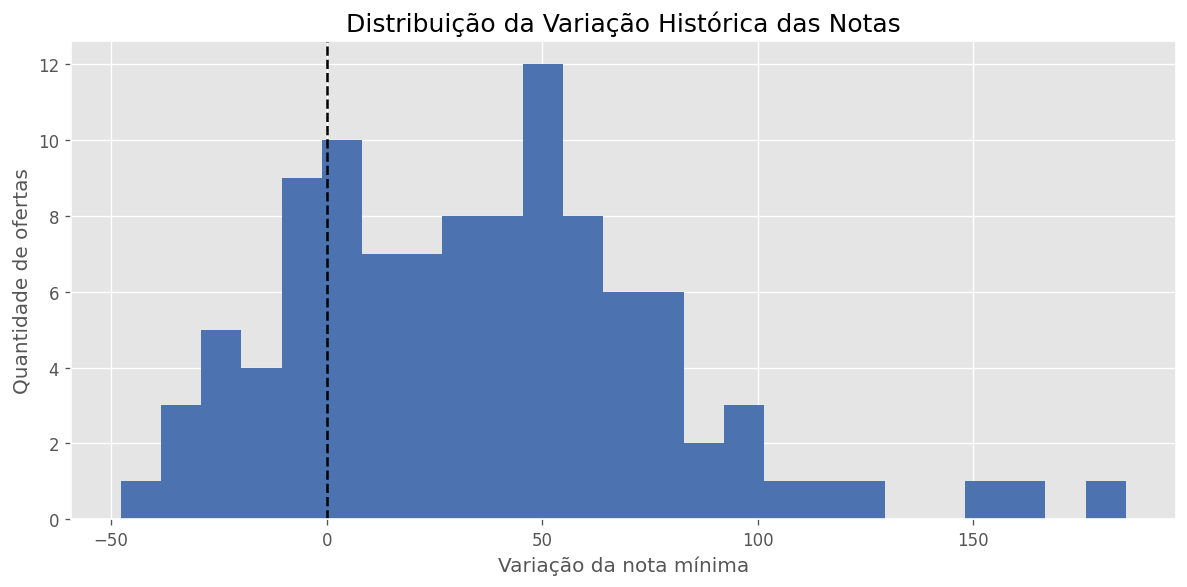

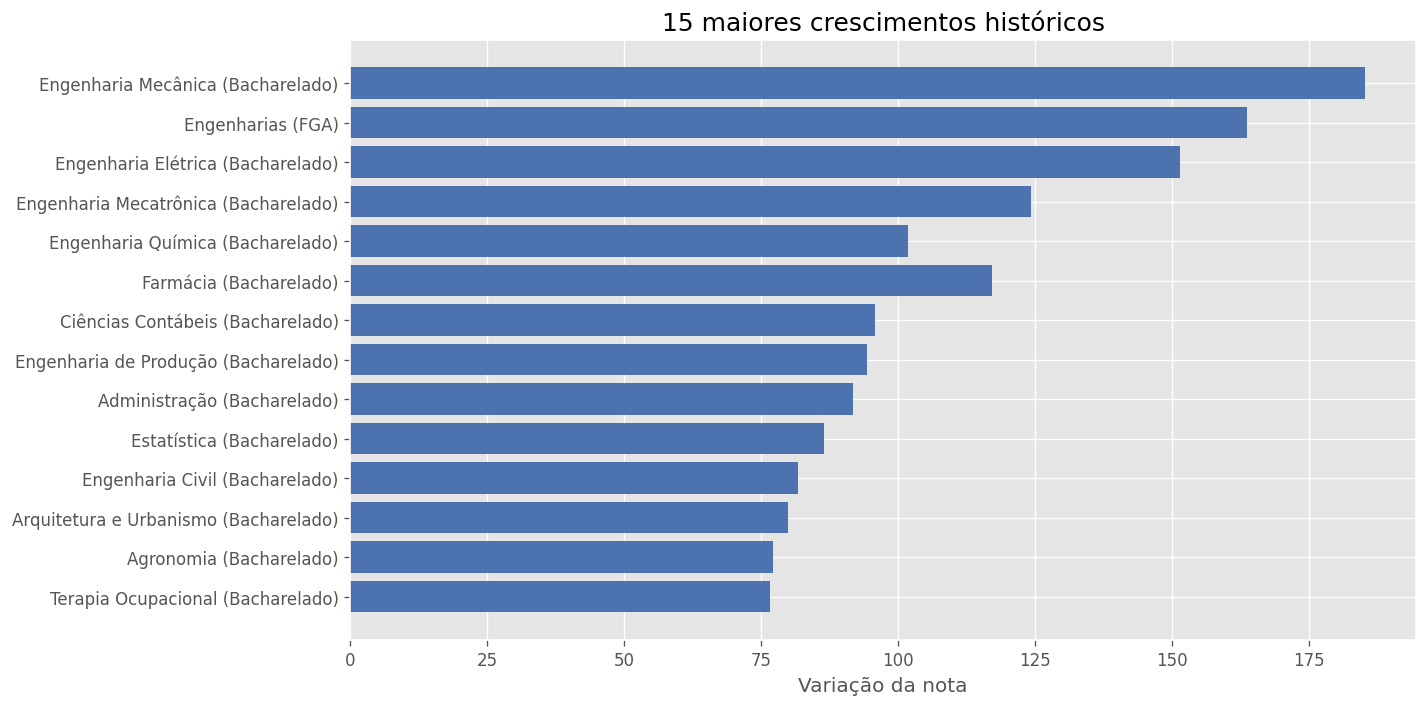

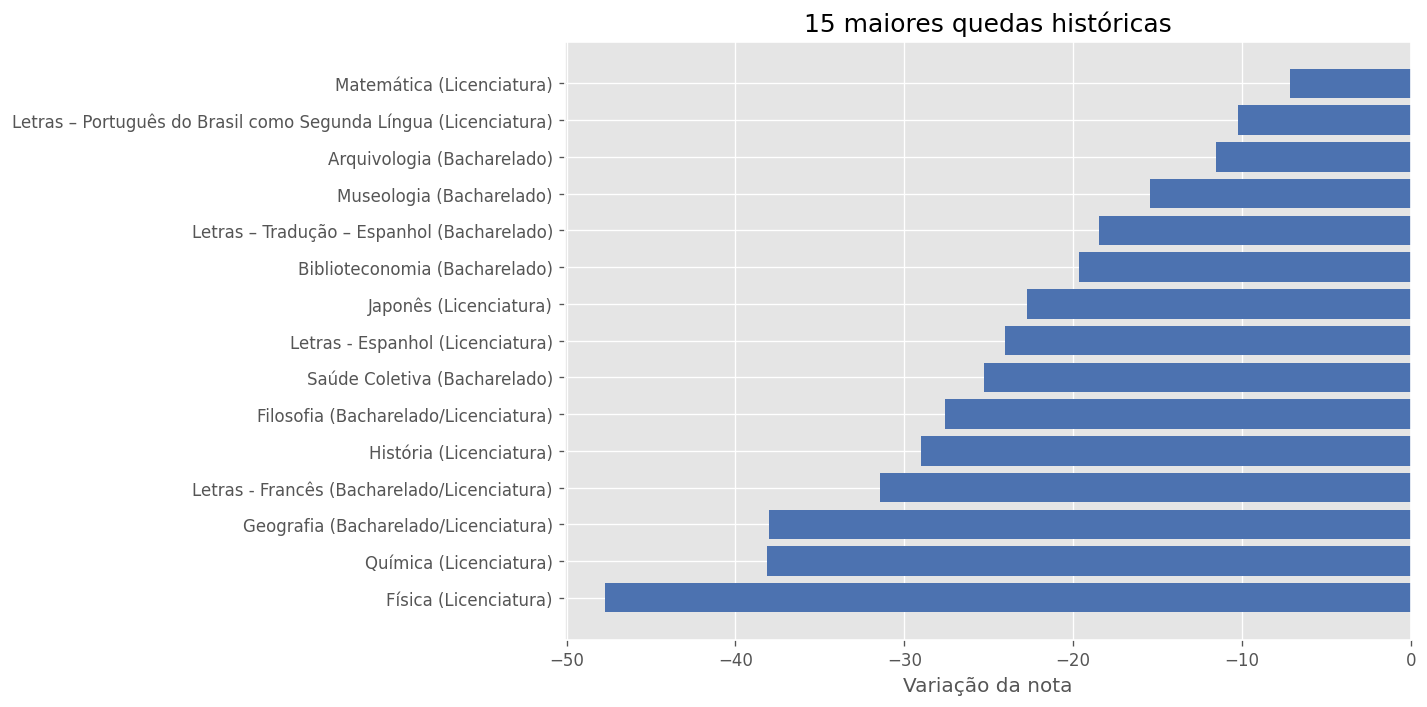

In [21]:
# ==============================================================================
# 12. EVOLUÇÃO HISTÓRICA DAS NOTAS DE CORTE
# ==============================================================================

print("=" * 80)
print("EVOLUÇÃO HISTÓRICA DAS NOTAS DE CORTE")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base da Ampla Concorrência
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ------------------------------------------------------------------------------
# Crescimento absoluto
# ------------------------------------------------------------------------------

ac["variacao_absoluta"] = (
    ac["ultima_nota_min"] -
    ac["primeira_nota_min"]
)

# ------------------------------------------------------------------------------
# Crescimento percentual
# ------------------------------------------------------------------------------

ac["variacao_percentual"] = np.where(

    ac["primeira_nota_min"] != 0,

    100 *
    ac["variacao_absoluta"] /
    ac["primeira_nota_min"],

    np.nan

)

# ==============================================================================
# ESTATÍSTICAS GERAIS
# ==============================================================================

display(

    ac[
        [
            "variacao_absoluta",
            "variacao_percentual"
        ]
    ].describe()

)

# ==============================================================================
# CURSOS QUE MAIS CRESCERAM
# ==============================================================================

maiores_altas = (

    ac

    .sort_values(
        "variacao_absoluta",
        ascending=False
    )

    [[
        "curso",
        "campus",
        "turno",
        "primeira_nota_min",
        "ultima_nota_min",
        "variacao_absoluta"
    ]]

    .head(15)

)

print("\nCURSOS COM MAIOR CRESCIMENTO\n")

display(maiores_altas)

# ==============================================================================
# CURSOS QUE MAIS CAÍRAM
# ==============================================================================

maiores_quedas = (

    ac

    .sort_values(
        "variacao_absoluta"
    )

    [[
        "curso",
        "campus",
        "turno",
        "primeira_nota_min",
        "ultima_nota_min",
        "variacao_absoluta"
    ]]

    .head(15)

)

print("\nCURSOS COM MAIOR QUEDA\n")

display(maiores_quedas)

# ==============================================================================
# DISTRIBUIÇÃO DAS VARIAÇÕES
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["variacao_absoluta"],
    bins=25
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Distribuição da Variação Histórica das Notas")

plt.xlabel("Variação da nota mínima")

plt.ylabel("Quantidade de ofertas")

plt.tight_layout()

plt.show()

# ==============================================================================
# MAIORES ALTAS
# ==============================================================================

plt.figure(figsize=(12,6))

grafico = maiores_altas.sort_values("variacao_absoluta")

plt.barh(

    grafico["curso"],

    grafico["variacao_absoluta"]

)

plt.title("15 maiores crescimentos históricos")

plt.xlabel("Variação da nota")

plt.tight_layout()

plt.show()

# ==============================================================================
# MAIORES QUEDAS
# ==============================================================================

plt.figure(figsize=(12,6))

grafico = maiores_quedas.sort_values("variacao_absoluta")

plt.barh(

    grafico["curso"],

    grafico["variacao_absoluta"]

)

plt.title("15 maiores quedas históricas")

plt.xlabel("Variação da nota")

plt.tight_layout()

plt.show()

# Seção 6 - Estabilidade Histórica e Volatilidade das Notas de Corte

ESTABILIDADE HISTÓRICA DAS NOTAS


,count,mean,std,min,25%,50%,75%,max
coef_var_min,105.0,-5.727286,392.753776,-1002.481,-80.304,-21.442,24.469,3541.599
desvio_historico_min,105.0,25.741267,16.271251,0.000,14.716,20.965,35.264,83.046
amplitude_historica_min,105.0,61.951590,38.694184,0.000,36.969,52.174,80.875,190.354
consistencia_min,105.0,66.984143,14.243935,50.000,60.000,60.000,75.000,100.000
volatilidade_min,105.0,39.375600,28.148199,0.000,20.737,29.974,51.262,146.328


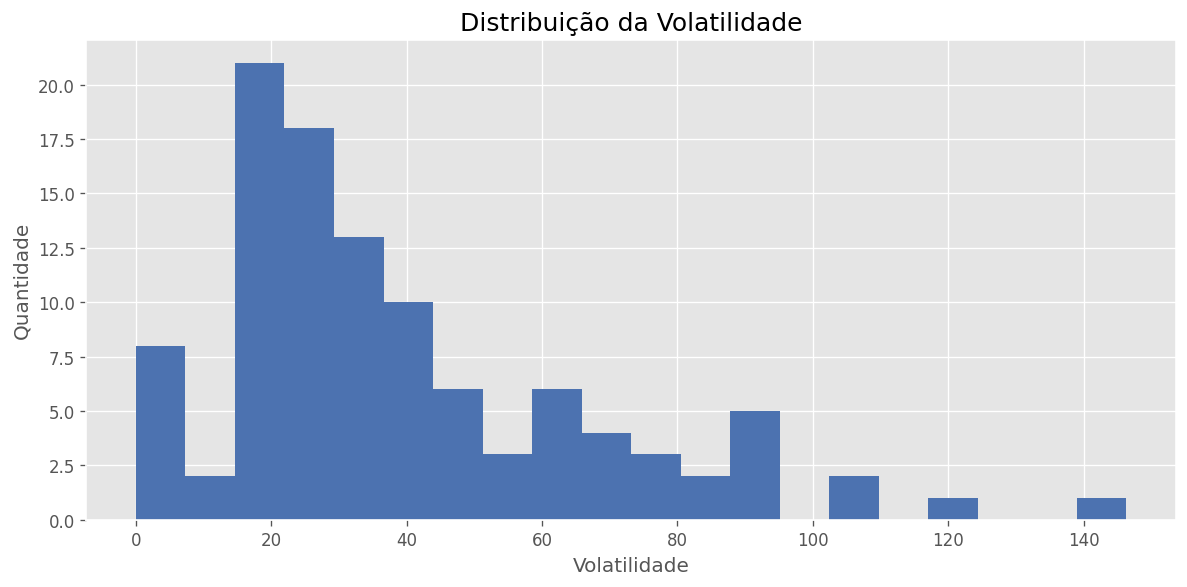

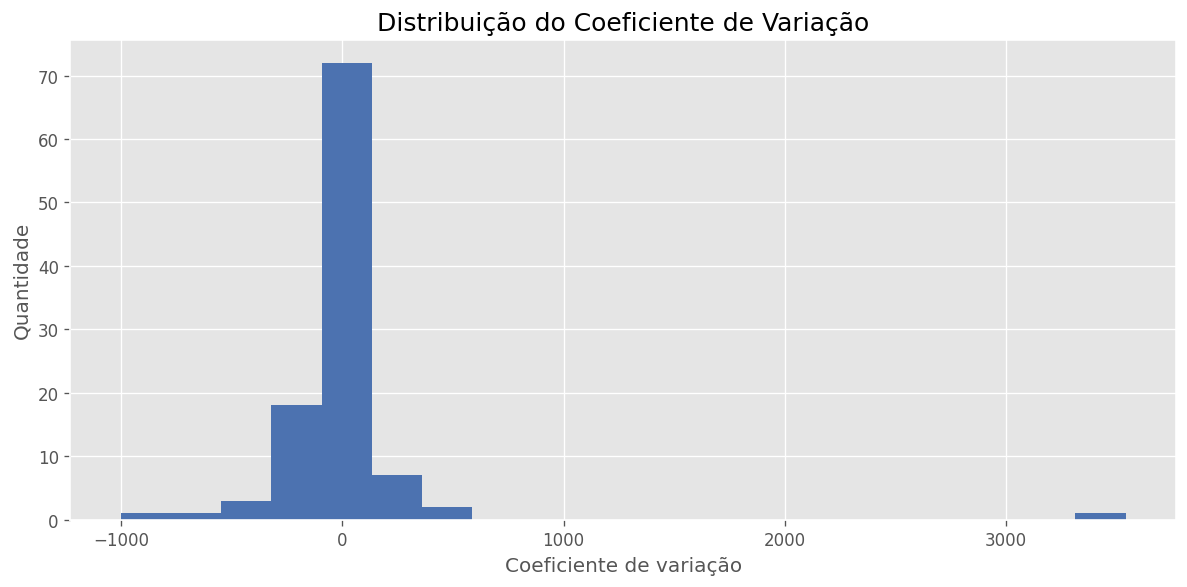


20 CURSOS MAIS ESTÁVEIS



,curso,campus,turno,coef_var_min,volatilidade_min,consistencia_min
389,Farmácia (Bacharelado),Ceilândia,Diurno,-1002.481,38.212,60.000
353,Engenharia de Produção (Bacharelado),Darcy Ribeiro,Noturno,-623.961,89.782,60.000
381,Estatística (Bacharelado),Darcy Ribeiro,Diurno,-466.563,92.785,60.000
438,Fonoaudiologia (Bacharelado),Ceilândia,Diurno,-449.668,29.659,80.000
47,Artes Cênicas (Bacharelado),Darcy Ribeiro,Diurno,-429.767,20.519,60.000
362,Engenharia de Redes de Comunicação (Bacharelado),Darcy Ribeiro,Diurno,-312.787,64.401,60.000
286,Engenharia Ambiental (Bacharelado),Darcy Ribeiro,Diurno,-285.665,65.514,50.000
144,Ciências Contábeis (Bacharelado),Darcy Ribeiro,Diurno,-243.374,92.453,60.000
591,Matemática (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-242.572,63.129,60.000
391,Farmácia (Bacharelado),Darcy Ribeiro,Noturno,-233.143,73.882,80.000



20 CURSOS MAIS INSTÁVEIS



,curso,campus,turno,coef_var_min,volatilidade_min,consistencia_min
249,Educação Física (Bacharelado),Darcy Ribeiro,Diurno,3541.599,21.761,100.0
690,Química (Bacharelado),Darcy Ribeiro,Diurno,495.446,39.688,60.0
448,Física (Bacharelado),Darcy Ribeiro,Diurno,374.330,91.808,50.0
326,Engenharia Mecânica (Bacharelado),Darcy Ribeiro,Diurno,284.823,121.536,60.0
302,Engenharia Elétrica (Bacharelado),Darcy Ribeiro,Diurno,264.102,146.328,75.0
371,Engenharias (FGA),Gama,Diurno,249.191,73.662,80.0
335,Engenharia Química (Bacharelado),Darcy Ribeiro,Diurno,197.837,83.928,60.0
549,Letras - Português (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,170.163,60.077,60.0
541,Letras - Inglês (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,163.770,35.789,60.0
26,Arquitetura e Urbanismo (Bacharelado),Darcy Ribeiro,Noturno,153.954,50.006,80.0


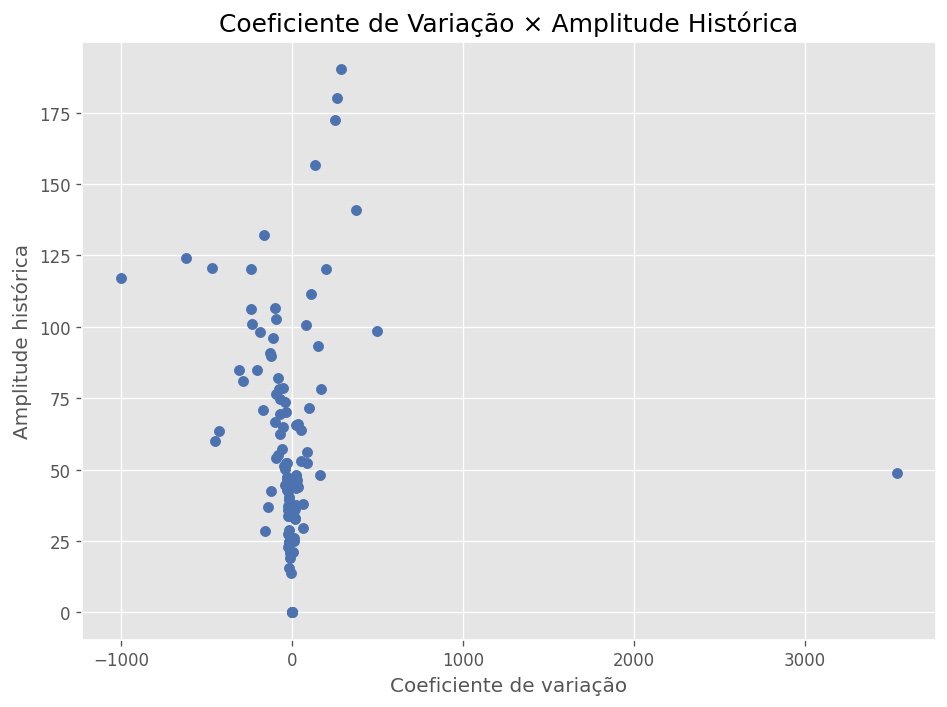

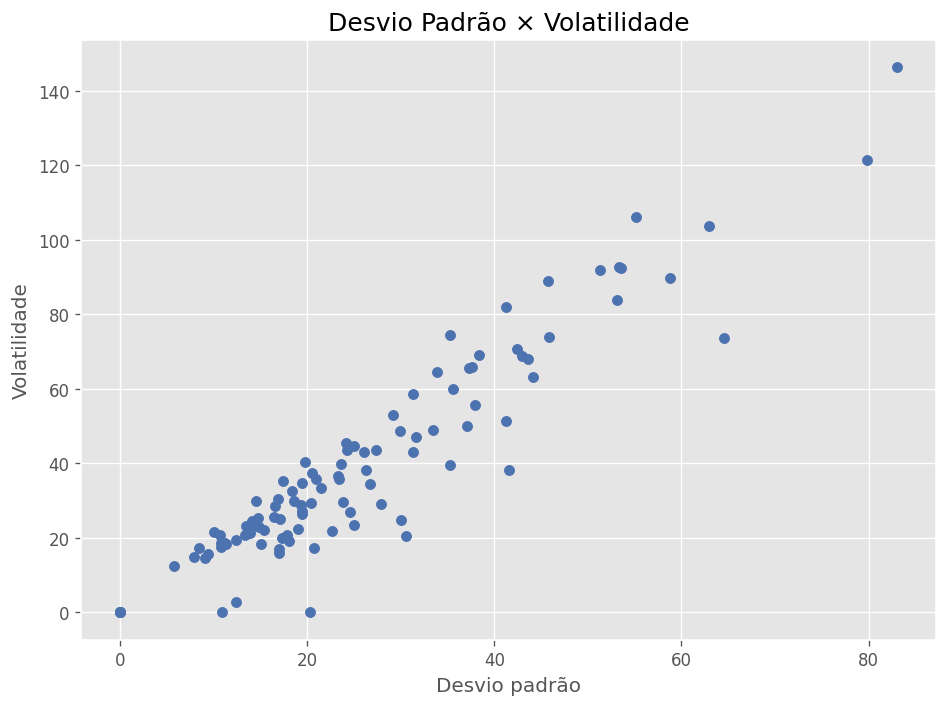

In [22]:
# ==============================================================================
# 13. ESTABILIDADE HISTÓRICA E VOLATILIDADE
# ==============================================================================

print("=" * 80)
print("ESTABILIDADE HISTÓRICA DAS NOTAS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ==============================================================================
# ESTATÍSTICAS DESCRITIVAS
# ==============================================================================

variaveis = [

    "coef_var_min",
    "desvio_historico_min",
    "amplitude_historica_min",
    "consistencia_min",
    "volatilidade_min"

]

display(
    ac[variaveis]
    .describe()
    .T
)

# ==============================================================================
# DISTRIBUIÇÃO DA VOLATILIDADE
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["volatilidade_min"],
    bins=20
)

plt.title("Distribuição da Volatilidade")

plt.xlabel("Volatilidade")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# DISTRIBUIÇÃO DO COEFICIENTE DE VARIAÇÃO
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["coef_var_min"],
    bins=20
)

plt.title("Distribuição do Coeficiente de Variação")

plt.xlabel("Coeficiente de variação")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# CURSOS MAIS ESTÁVEIS
# ==============================================================================

mais_estaveis = (

    ac

    .sort_values(

        by=[
            "coef_var_min",
            "volatilidade_min"
        ]

    )

    [[

        "curso",
        "campus",
        "turno",
        "coef_var_min",
        "volatilidade_min",
        "consistencia_min"

    ]]

    .head(20)

)

print("\n20 CURSOS MAIS ESTÁVEIS\n")

display(mais_estaveis)

# ==============================================================================
# CURSOS MAIS INSTÁVEIS
# ==============================================================================

mais_instaveis = (

    ac

    .sort_values(

        by=[
            "coef_var_min",
            "volatilidade_min"
        ],

        ascending=False

    )

    [[

        "curso",
        "campus",
        "turno",
        "coef_var_min",
        "volatilidade_min",
        "consistencia_min"

    ]]

    .head(20)

)

print("\n20 CURSOS MAIS INSTÁVEIS\n")

display(mais_instaveis)

# ==============================================================================
# DISPERSÃO
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    ac["coef_var_min"],

    ac["amplitude_historica_min"]

)

plt.title("Coeficiente de Variação × Amplitude Histórica")

plt.xlabel("Coeficiente de variação")

plt.ylabel("Amplitude histórica")

plt.tight_layout()

plt.show()

# ==============================================================================
# DISPERSÃO
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    ac["desvio_historico_min"],

    ac["volatilidade_min"]

)

plt.title("Desvio Padrão × Volatilidade")

plt.xlabel("Desvio padrão")

plt.ylabel("Volatilidade")

plt.tight_layout()

plt.show()

# Seção 7 - Convergência entre os Modelos Preditivos

CONVERGÊNCIA ENTRE OS MODELOS


,count,mean,std,min,25%,50%,75%,max
ensemble_min,105.0,0.787076,59.723864,-85.947,-51.211,-5.390,46.968,167.330
ensemble_desvio_min,105.0,9.512267,6.134010,0.000,4.819,8.484,13.505,27.126
ensemble_amplitude_min,105.0,21.114124,13.556729,0.000,10.300,18.646,29.931,57.936
ensemble_n_modelos_min,105.0,3.904762,0.427960,2.000,4.000,4.000,4.000,4.000


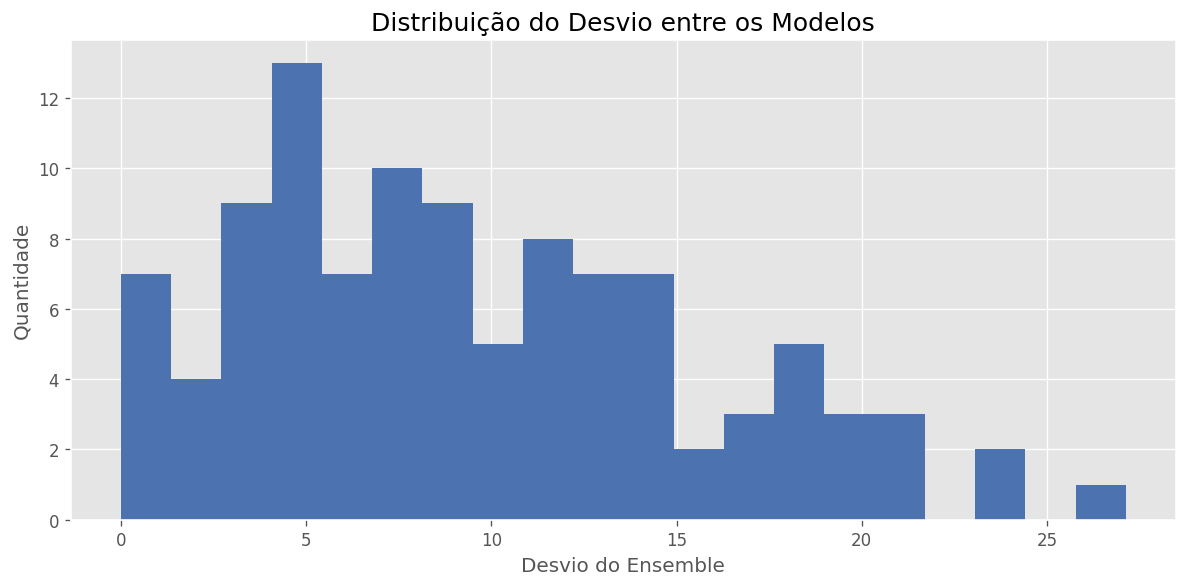

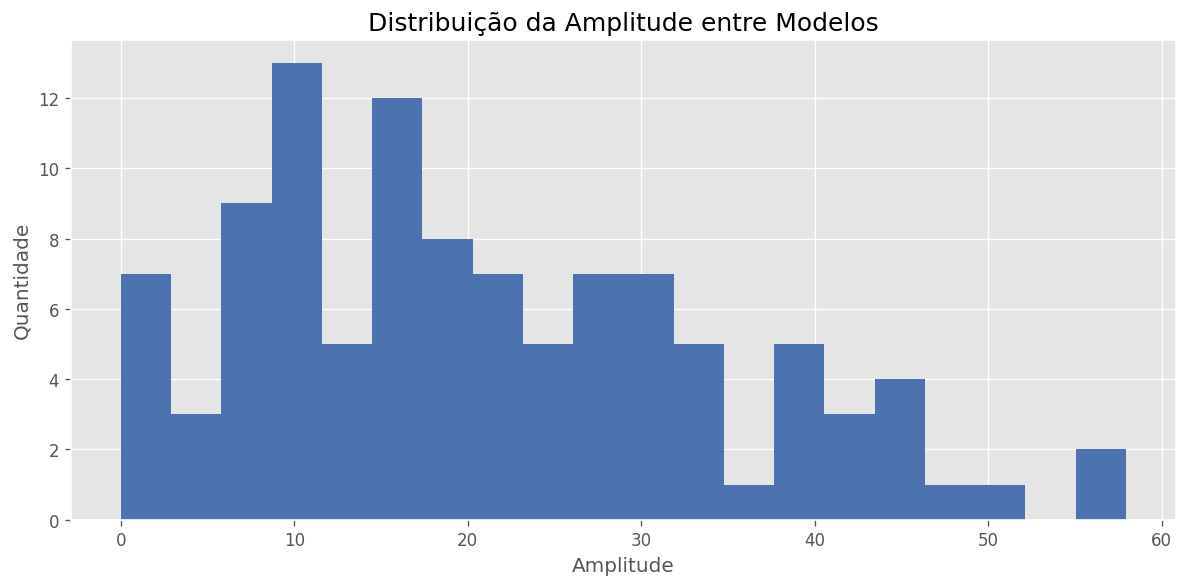


20 CURSOS COM MAIOR CONSENSO ENTRE OS MODELOS



,curso,campus,turno,ensemble_min,ensemble_desvio_min,ensemble_amplitude_min
54,Artes Cênicas (Licenciatura),Darcy Ribeiro,Diurno,-12.384,0.000,0.000
55,Artes Cênicas (Licenciatura),Darcy Ribeiro,Noturno,-53.375,0.000,0.000
59,Artes Cênicas (Literatura),Darcy Ribeiro,Noturno,-68.863,0.000,0.000
70,Artes Visuais (Licenciatura),Darcy Ribeiro,Noturno,-13.502,0.000,0.000
94,Biologia (Licenciatura),Darcy Ribeiro,Diurno,61.373,0.000,0.000
170,Ciências Naturais (Licenciatura),Planaltina,Diurno,-79.138,0.568,1.376
732,Serviço Social (Bacharelado),Darcy Ribeiro,Noturno,-62.333,1.022,2.260
677,Psicologia (Bacharelado / Licenciatura / Psicólogo),Darcy Ribeiro,Diurno,92.075,1.890,4.510
719,Saúde Coletiva (Bacharelado),Ceilândia,Diurno,-74.118,2.177,4.512
522,Jornalismo (Bacharelado),Darcy Ribeiro,Diurno,82.985,2.060,4.768



20 CURSOS COM MAIOR DIVERGÊNCIA ENTRE OS MODELOS



,curso,campus,turno,ensemble_min,ensemble_desvio_min,ensemble_amplitude_min
371,Engenharias (FGA),Gama,Diurno,70.154,24.314,57.936
353,Engenharia de Produção (Bacharelado),Darcy Ribeiro,Noturno,8.806,27.126,57.669
302,Engenharia Elétrica (Bacharelado),Darcy Ribeiro,Diurno,79.656,23.968,51.635
466,Geografia (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,-76.643,21.342,46.938
326,Engenharia Mecânica (Bacharelado),Darcy Ribeiro,Diurno,68.331,21.154,45.515
576,Letras – Tradução – Inglês (Bacharelado),Darcy Ribeiro,Diurno,-63.319,20.328,45.089
389,Farmácia (Bacharelado),Ceilândia,Diurno,33.942,18.593,44.554
488,Gestão de Políticas Públicas (Bacharelado),Darcy Ribeiro,Noturno,-2.159,20.551,44.416
194,Comunicação Organizacional (Bacharelado),Darcy Ribeiro,Noturno,-19.181,18.874,42.531
69,Artes Visuais (Licenciatura),Darcy Ribeiro,Diurno,-17.070,18.356,41.592


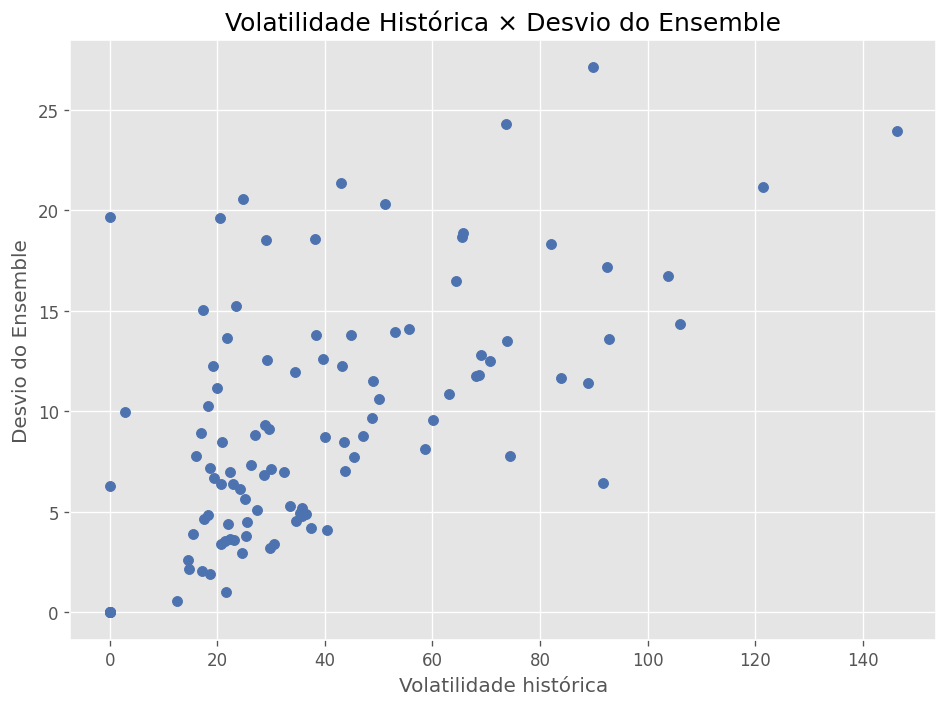

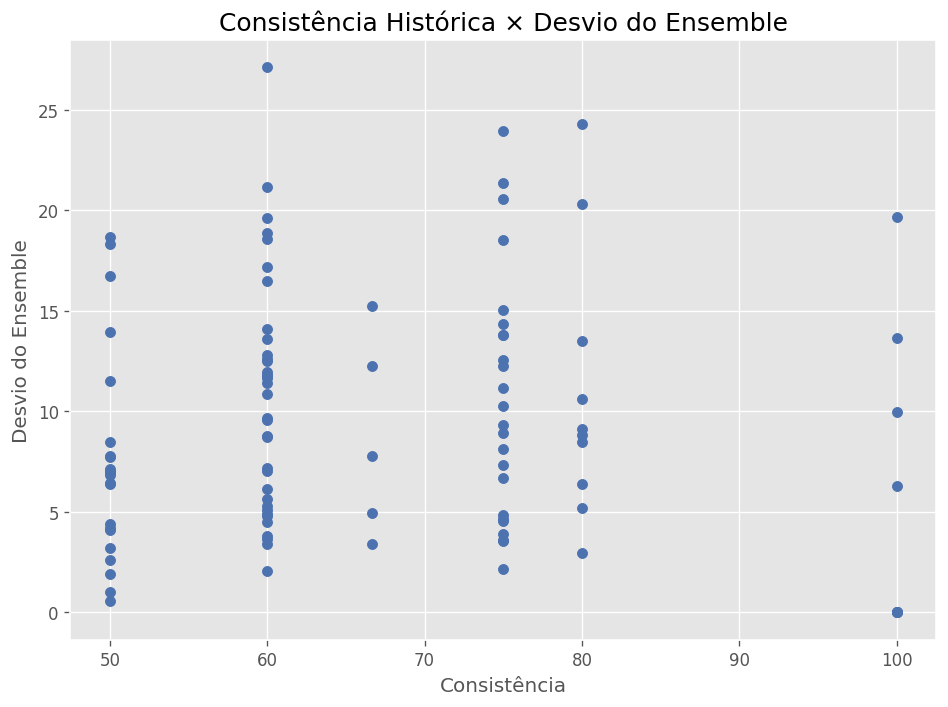

,coef_var_min,volatilidade_min,consistencia_min,ensemble_desvio_min,ensemble_amplitude_min
coef_var_min,1.000000,-0.056895,0.218874,-0.072892,-0.076218
volatilidade_min,-0.056895,1.000000,-0.349879,0.601959,0.611666
consistencia_min,0.218874,-0.349879,1.000000,-0.036885,-0.053495
ensemble_desvio_min,-0.072892,0.601959,-0.036885,1.000000,0.995584
ensemble_amplitude_min,-0.076218,0.611666,-0.053495,0.995584,1.000000


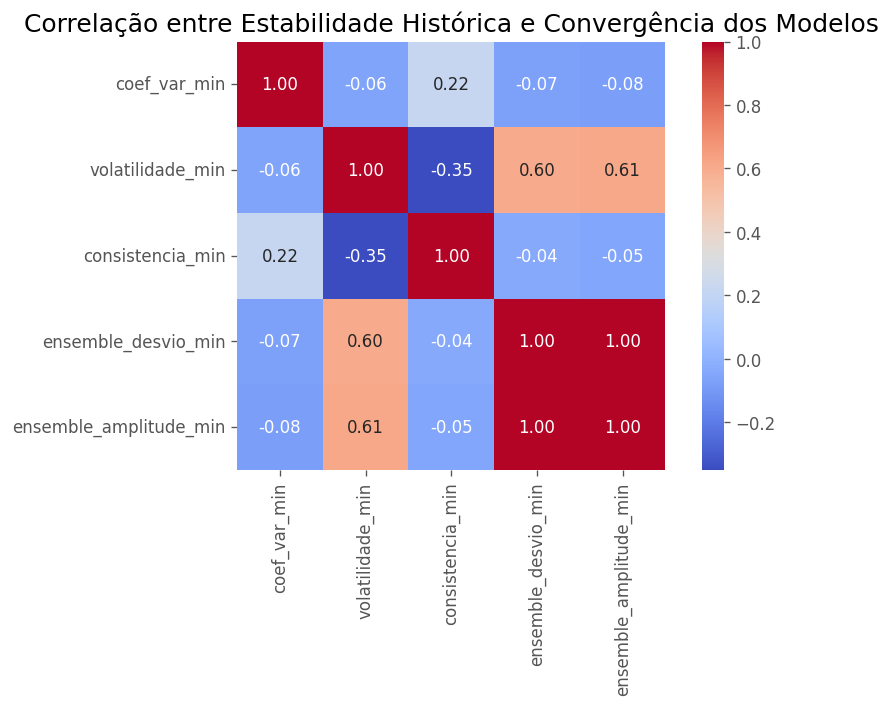

In [23]:
# ==============================================================================
# 14. CONVERGÊNCIA ENTRE OS MODELOS PREDITIVOS
# ==============================================================================

print("=" * 80)
print("CONVERGÊNCIA ENTRE OS MODELOS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base da AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ==============================================================================
# ESTATÍSTICAS DESCRITIVAS
# ==============================================================================

variaveis = [

    "ensemble_min",
    "ensemble_desvio_min",
    "ensemble_amplitude_min",
    "ensemble_n_modelos_min"

]

display(ac[variaveis].describe().T)

# ==============================================================================
# HISTOGRAMA DA DISPERSÃO
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["ensemble_desvio_min"],
    bins=20
)

plt.title("Distribuição do Desvio entre os Modelos")

plt.xlabel("Desvio do Ensemble")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# HISTOGRAMA DA AMPLITUDE
# ==============================================================================

plt.figure(figsize=(10,5))

plt.hist(
    ac["ensemble_amplitude_min"],
    bins=20
)

plt.title("Distribuição da Amplitude entre Modelos")

plt.xlabel("Amplitude")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# CURSOS COM MAIOR CONSENSO
# ==============================================================================

consenso = (

    ac

    .sort_values(

        by=[
            "ensemble_amplitude_min",
            "ensemble_desvio_min"
        ]

    )

    [[

        "curso",
        "campus",
        "turno",
        "ensemble_min",
        "ensemble_desvio_min",
        "ensemble_amplitude_min"

    ]]

    .head(20)

)

print("\n20 CURSOS COM MAIOR CONSENSO ENTRE OS MODELOS\n")

display(consenso)

# ==============================================================================
# CURSOS COM MAIOR DIVERGÊNCIA
# ==============================================================================

divergencia = (

    ac

    .sort_values(

        by=[
            "ensemble_amplitude_min",
            "ensemble_desvio_min"
        ],

        ascending=False

    )

    [[

        "curso",
        "campus",
        "turno",
        "ensemble_min",
        "ensemble_desvio_min",
        "ensemble_amplitude_min"

    ]]

    .head(20)

)

print("\n20 CURSOS COM MAIOR DIVERGÊNCIA ENTRE OS MODELOS\n")

display(divergencia)

# ==============================================================================
# DISPERSÃO ENTRE ESTABILIDADE E CONVERGÊNCIA
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    ac["volatilidade_min"],

    ac["ensemble_desvio_min"]

)

plt.title("Volatilidade Histórica × Desvio do Ensemble")

plt.xlabel("Volatilidade histórica")

plt.ylabel("Desvio do Ensemble")

plt.tight_layout()

plt.show()

# ==============================================================================
# DISPERSÃO ENTRE CONSISTÊNCIA E CONVERGÊNCIA
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    ac["consistencia_min"],

    ac["ensemble_desvio_min"]

)

plt.title("Consistência Histórica × Desvio do Ensemble")

plt.xlabel("Consistência")

plt.ylabel("Desvio do Ensemble")

plt.tight_layout()

plt.show()

# ==============================================================================
# MATRIZ DE CORRELAÇÃO
# ==============================================================================

correlacao = ac[[
    "coef_var_min",
    "volatilidade_min",
    "consistencia_min",
    "ensemble_desvio_min",
    "ensemble_amplitude_min"
]].corr()

display(correlacao)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlação entre Estabilidade Histórica e Convergência dos Modelos")

plt.tight_layout()

plt.show()

# Seção 8 - Clusterização dos Perfis Históricos dos Cursos

CLUSTERIZAÇÃO DOS CURSOS


,Cursos
cluster,
0,53
1,5
2,39
3,7
4,1


,variacao_historica,coef_var_min,desvio_historico_min,amplitude_historica_min,volatilidade_min,consistencia_min,ensemble_desvio_min,ensemble_amplitude_min
cluster,,,,,,,,
0,16.55,-10.36,16.58,41.23,26.09,63.58,5.81,12.93
1,143.86,61.11,69.81,164.69,107.02,65.00,22.66,50.59
2,52.91,-98.98,36.64,87.37,56.21,65.09,14.05,31.17
3,5.72,-5.62,3.32,5.72,0.41,100.00,2.32,4.77
4,48.85,3541.60,22.67,48.85,21.76,100.00,13.64,29.93




CLUSTER 0


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min
0,Administração (Bacharelado),Darcy Ribeiro,Diurno,43.944,87.136,35.681
25,Arquitetura e Urbanismo (Bacharelado),Darcy Ribeiro,Diurno,32.061,16.777,20.718
41,Arquivologia (Bacharelado),Darcy Ribeiro,Noturno,-11.565,-22.257,21.444
76,Biblioteconomia (Bacharelado),Darcy Ribeiro,Diurno,-19.627,-28.248,29.974
83,Biologia (Bacharelado),Darcy Ribeiro,Diurno,31.154,28.811,34.700
95,Biologia (Licenciatura),Darcy Ribeiro,Noturno,21.855,-125.359,40.424
126,Ciência da Computação (Bacharelado),Darcy Ribeiro,Diurno,57.524,20.409,27.083
139,Ciências Ambientais (Bacharelado),Darcy Ribeiro,Noturno,26.019,-23.596,28.636
145,Ciências Contábeis (Bacharelado),Darcy Ribeiro,Noturno,43.513,-48.493,43.568
161,Ciências Econômicas (Bacharelado),Darcy Ribeiro,Diurno,58.431,34.504,43.650


...

,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min
1,Administração (Bacharelado),Darcy Ribeiro,Noturno,91.850,-113.060,68.732
16,Agronomia (Bacharelado),Darcy Ribeiro,Diurno,77.185,-123.361,70.645
26,Arquitetura e Urbanismo (Bacharelado),Darcy Ribeiro,Noturno,79.960,153.954,50.006
47,Artes Cênicas (Bacharelado),Darcy Ribeiro,Diurno,59.642,-429.767,20.519
58,Artes Cênicas (Literatura),Darcy Ribeiro,Diurno,51.088,-168.312,74.411
65,Artes Visuais (Bacharelado),Darcy Ribeiro,Diurno,67.808,-189.563,55.730
69,Artes Visuais (Licenciatura),Darcy Ribeiro,Diurno,48.100,-80.304,82.029
107,Biotecnologia (Bacharelado),Darcy Ribeiro,Diurno,53.574,81.938,69.102
116,Ciência Política (Bacharelado),Darcy Ribeiro,Diurno,71.693,99.746,47.124
144,Ciências Contábeis (Bacharelado),Darcy Ribeiro,Diurno,95.841,-243.374,92.453




CLUSTER 3


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min
54,Artes Cênicas (Licenciatura),Darcy Ribeiro,Diurno,0.000,0.000,0.000
55,Artes Cênicas (Licenciatura),Darcy Ribeiro,Noturno,0.000,0.000,0.000
59,Artes Cênicas (Literatura),Darcy Ribeiro,Noturno,0.000,0.000,0.000
70,Artes Visuais (Licenciatura),Darcy Ribeiro,Noturno,0.000,0.000,0.000
94,Biologia (Licenciatura),Darcy Ribeiro,Diurno,0.000,0.000,0.000
171,Ciências Naturais (Licenciatura),Planaltina,Noturno,24.638,-19.374,2.841
479,Gestão Ambiental (Bacharelado),Planaltina,Noturno,15.395,-19.990,0.000




CLUSTER 4


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min
249,Educação Física (Bacharelado),Darcy Ribeiro,Diurno,48.851,3541.599,21.761


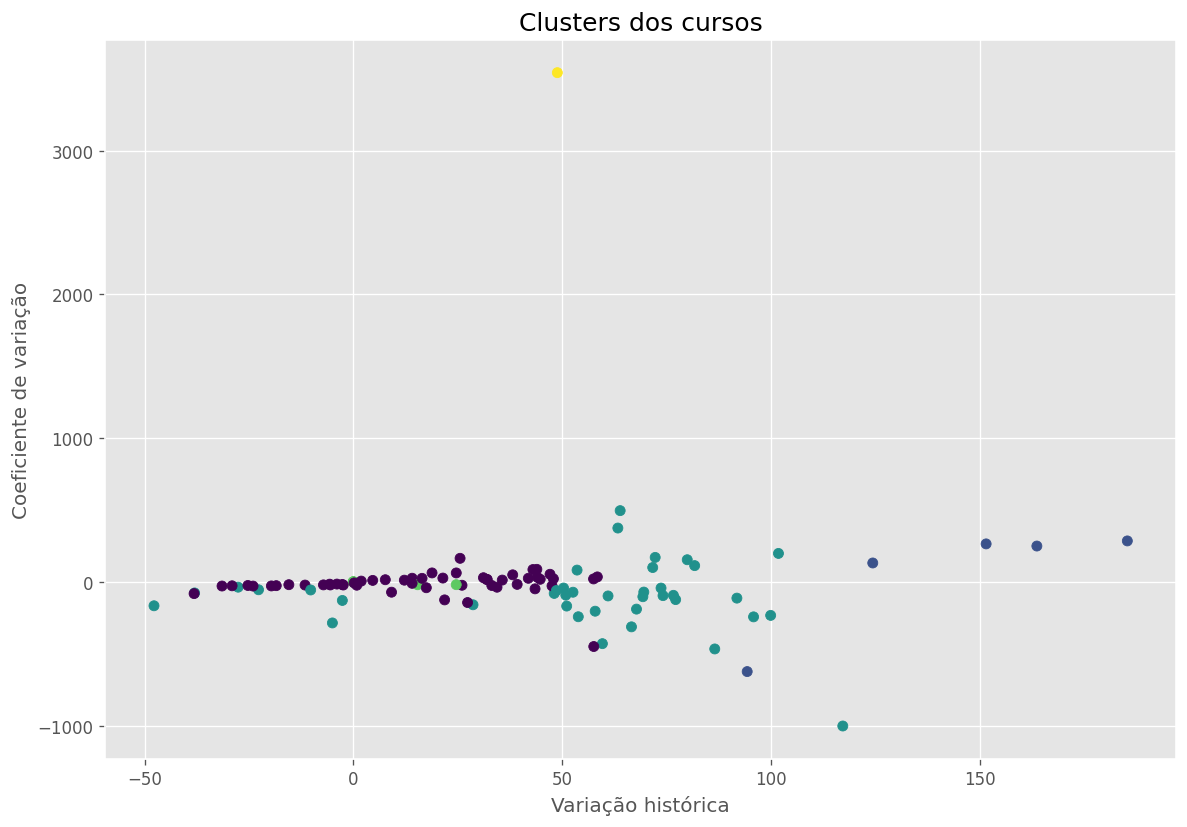

In [24]:
# ==============================================================================
# 15. CLUSTERIZAÇÃO DOS PERFIS DOS CURSOS
# ==============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("=" * 80)
print("CLUSTERIZAÇÃO DOS CURSOS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ------------------------------------------------------------------------------
# Crescimento histórico
# ------------------------------------------------------------------------------

ac["variacao_historica"] = (
    ac["ultima_nota_min"] -
    ac["primeira_nota_min"]
)

# ------------------------------------------------------------------------------
# Variáveis do modelo
# ------------------------------------------------------------------------------

variaveis_cluster = [

    "variacao_historica",

    "coef_var_min",

    "desvio_historico_min",

    "amplitude_historica_min",

    "volatilidade_min",

    "consistencia_min",

    "ensemble_desvio_min",

    "ensemble_amplitude_min"

]

X = ac[variaveis_cluster].copy()

# ------------------------------------------------------------------------------
# Padronização
# ------------------------------------------------------------------------------

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X)

# ------------------------------------------------------------------------------
# Clusterização
# ------------------------------------------------------------------------------

modelo = KMeans(

    n_clusters=5,
    random_state=42,
    n_init=20

)

ac["cluster"] = modelo.fit_predict(X_padronizado)

# ==============================================================================
# TAMANHO DOS CLUSTERS
# ==============================================================================

clusters = (

    ac["cluster"]

    .value_counts()

    .sort_index()

    .rename("Cursos")

)

display(clusters)

# ==============================================================================
# PERFIL MÉDIO DOS CLUSTERS
# ==============================================================================

perfil = (

    ac

    .groupby("cluster")[variaveis_cluster]

    .mean()

    .round(2)

)

display(perfil)

# ==============================================================================
# EXEMPLOS DE CURSOS
# ==============================================================================

for grupo in sorted(ac["cluster"].unique()):

    print("\n")
    print("=" * 60)
    print(f"CLUSTER {grupo}")
    print("=" * 60)

    display(

        ac.loc[
            ac["cluster"] == grupo,

            [

                "curso",

                "campus",

                "turno",

                "variacao_historica",

                "coef_var_min",

                "volatilidade_min"

            ]

        ].head(10)

    )

# ==============================================================================
# VISUALIZAÇÃO
# ==============================================================================

plt.figure(figsize=(10,7))

plt.scatter(

    ac["variacao_historica"],

    ac["coef_var_min"],

    c=ac["cluster"]

)

plt.xlabel("Variação histórica")

plt.ylabel("Coeficiente de variação")

plt.title("Clusters dos cursos")

plt.tight_layout()

plt.show()

# Seção 9 - Classificação Analítica dos Perfis dos Cursos

CLASSIFICAÇÃO ANALÍTICA DOS CURSOS


,Perfil,Cursos
0,Intermediário,56
1,Crescimento instável,24
2,Alta instabilidade,20
3,Queda consistente,4
4,Muito previsível,1




Alta instabilidade


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min,ensemble_amplitude_min
161,Ciências Econômicas (Bacharelado),Darcy Ribeiro,Diurno,58.431,34.504,43.650,14.316
591,Matemática (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,53.869,-242.572,63.129,23.016
107,Biotecnologia (Bacharelado),Darcy Ribeiro,Diurno,53.574,81.938,69.102,29.459
745,"Teoria, Crítica e História da Arte (Bacharelado)",Darcy Ribeiro,Noturno,52.599,-72.011,58.624,18.239
58,Artes Cênicas (Literatura),Darcy Ribeiro,Diurno,51.088,-168.312,74.411,17.073
249,Educação Física (Bacharelado),Darcy Ribeiro,Diurno,48.851,3541.599,21.761,29.931
69,Artes Visuais (Licenciatura),Darcy Ribeiro,Diurno,48.100,-80.304,82.029,41.592
268,Enfermagem (Bacharelado),Darcy Ribeiro,Diurno,47.099,52.789,33.467,11.300
641,Nutrição (Bacharelado),Darcy Ribeiro,Diurno,44.095,31.349,25.176,12.224
0,Administração (Bacharelado),Darcy Ribeiro,Diurno,43.944,87.136,35.681,9.443




Crescimento instável


...



Muito previsível


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min,ensemble_amplitude_min
95,Biologia (Licenciatura),Darcy Ribeiro,Noturno,21.855,-125.359,40.424,9.29




Queda consistente


,curso,campus,turno,variacao_historica,coef_var_min,volatilidade_min,ensemble_amplitude_min
576,Letras – Tradução – Inglês (Bacharelado),Darcy Ribeiro,Diurno,-2.635,-129.237,51.262,45.089
286,Engenharia Ambiental (Bacharelado),Darcy Ribeiro,Diurno,-5.017,-285.665,65.514,39.623
698,Química (Licenciatura),Darcy Ribeiro,Noturno,-38.138,-81.620,29.294,27.537
456,Física (Licenciatura),Darcy Ribeiro,Noturno,-47.738,-166.274,106.025,30.975


<Figure size 1200x600 with 0 Axes>

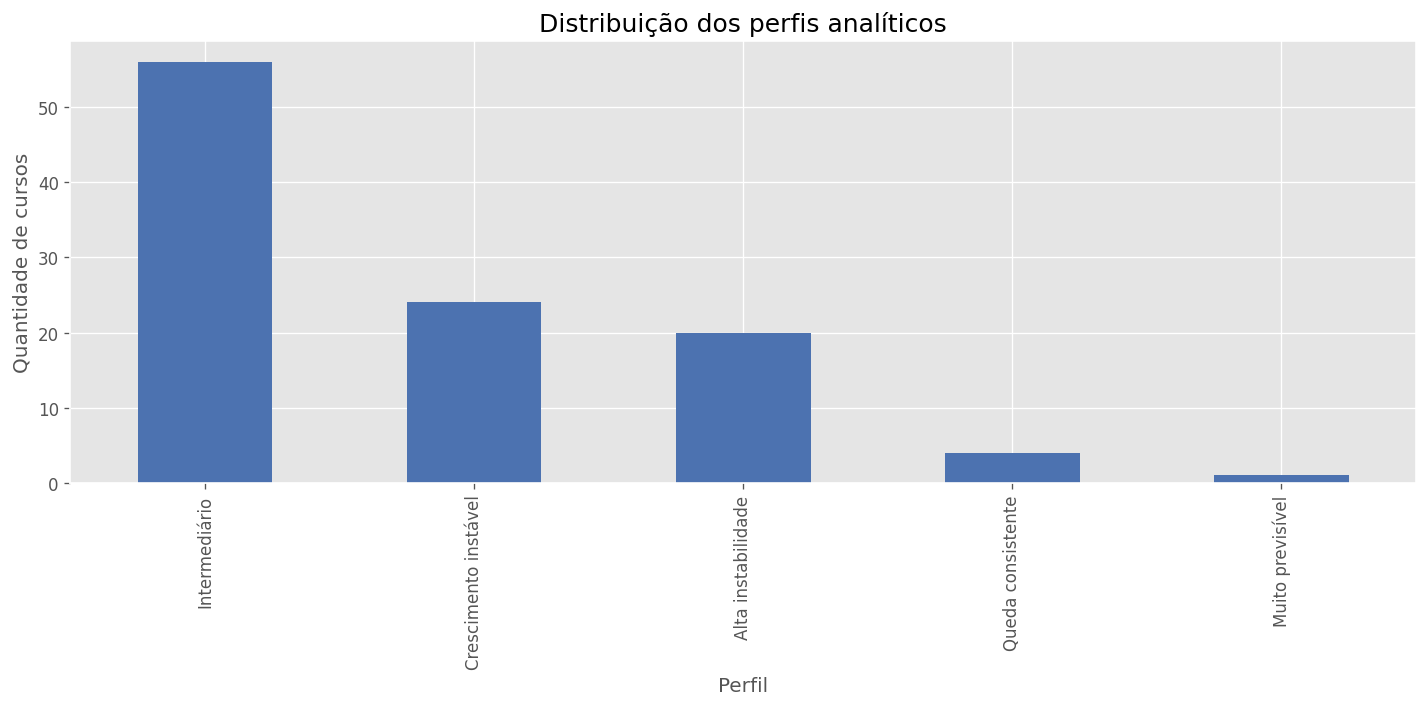

In [25]:
# ==============================================================================
# 16. CLASSIFICAÇÃO ANALÍTICA DOS CURSOS
# ==============================================================================

print("=" * 80)
print("CLASSIFICAÇÃO ANALÍTICA DOS CURSOS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ------------------------------------------------------------------------------
# Crescimento histórico
# ------------------------------------------------------------------------------

ac["variacao_historica"] = (
    ac["ultima_nota_min"] -
    ac["primeira_nota_min"]
)

# ------------------------------------------------------------------------------
# Quartis
# ------------------------------------------------------------------------------

ac["q_crescimento"] = pd.qcut(
    ac["variacao_historica"],
    q=4,
    labels=False,
    duplicates="drop"
)

ac["q_estabilidade"] = pd.qcut(
    ac["coef_var_min"],
    q=4,
    labels=False,
    duplicates="drop"
)

ac["q_volatilidade"] = pd.qcut(
    ac["volatilidade_min"],
    q=4,
    labels=False,
    duplicates="drop"
)

ac["q_ensemble"] = pd.qcut(
    ac["ensemble_amplitude_min"],
    q=4,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------------------------------------
# Classificação
# ------------------------------------------------------------------------------

def classificar_perfil(linha):

    crescimento = linha["q_crescimento"]
    estabilidade = linha["q_estabilidade"]
    volatilidade = linha["q_volatilidade"]
    ensemble = linha["q_ensemble"]

    if (
        crescimento == 3
        and estabilidade == 0
        and volatilidade == 0
    ):
        return "Crescimento consistente"

    if (
        crescimento == 3
        and volatilidade >= 2
    ):
        return "Crescimento instável"

    if (
        crescimento == 0
        and estabilidade == 0
    ):
        return "Queda consistente"

    if (
        estabilidade == 0
        and ensemble == 0
    ):
        return "Muito previsível"

    if (
        estabilidade == 3
        or volatilidade == 3
    ):
        return "Alta instabilidade"

    return "Intermediário"

ac["perfil"] = ac.apply(
    classificar_perfil,
    axis=1
)

# ==============================================================================
# DISTRIBUIÇÃO DOS PERFIS
# ==============================================================================

perfil = (
    ac["perfil"]
    .value_counts()
    .rename_axis("Perfil")
    .reset_index(name="Cursos")
)

display(perfil)

# ==============================================================================
# CURSOS POR PERFIL
# ==============================================================================

for nome in sorted(ac["perfil"].unique()):

    print("\n")
    print("=" * 80)
    print(nome)
    print("=" * 80)

    display(

        ac.loc[
            ac["perfil"] == nome,

            [
                "curso",
                "campus",
                "turno",
                "variacao_historica",
                "coef_var_min",
                "volatilidade_min",
                "ensemble_amplitude_min"
            ]

        ].sort_values(
            "variacao_historica",
            ascending=False
        )

    )

# ==============================================================================
# GRÁFICO
# ==============================================================================

plt.figure(figsize=(10,5))

perfil.plot.bar(
    x="Perfil",
    y="Cursos",
    legend=False
)

plt.title("Distribuição dos perfis analíticos")

plt.ylabel("Quantidade de cursos")

plt.tight_layout()

plt.show()

# Seção 10 - Inteligência Analítica por Campus

INTELIGÊNCIA ANALÍTICA POR CAMPUS


,ofertas,media_nota,crescimento,volatilidade,coef_var,consistencia,amplitude,desvio_ensemble,amplitude_ensemble
campus,,,,,,,,,
Gama,1,25.90,163.69,73.66,249.19,80.00,172.37,24.31,57.94
Darcy Ribeiro,94,-4.87,34.45,40.97,6.87,66.37,62.74,9.64,21.33
Ceilândia,6,-11.91,51.50,27.36,-238.60,69.17,56.75,8.07,18.68
Planaltina,4,-69.24,9.39,11.32,-16.25,75.00,23.59,5.01,10.48


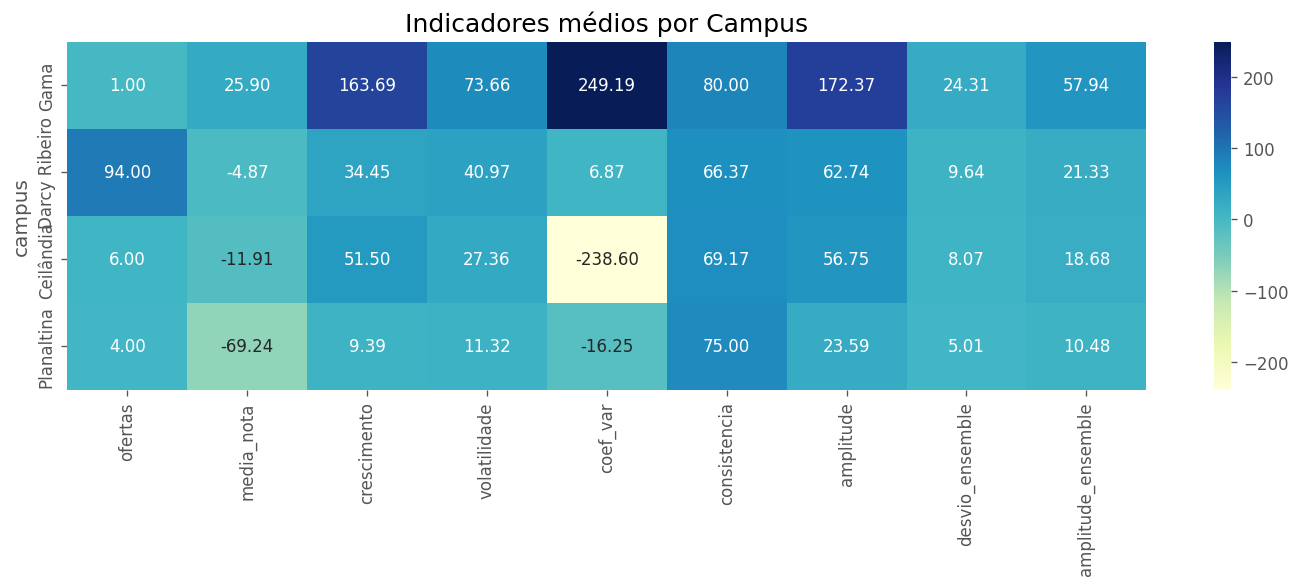

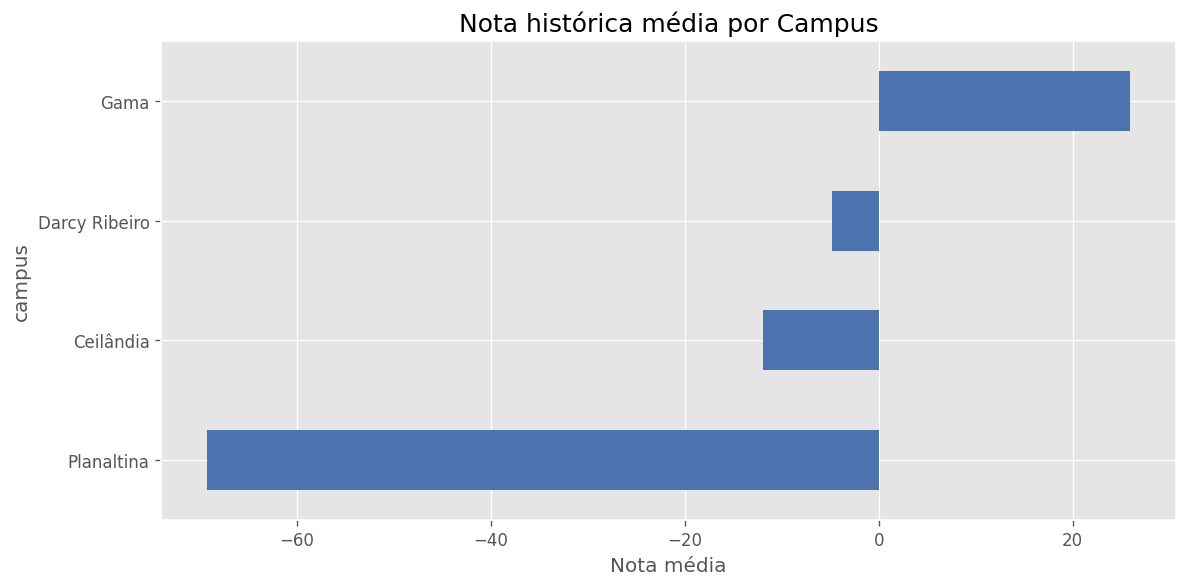

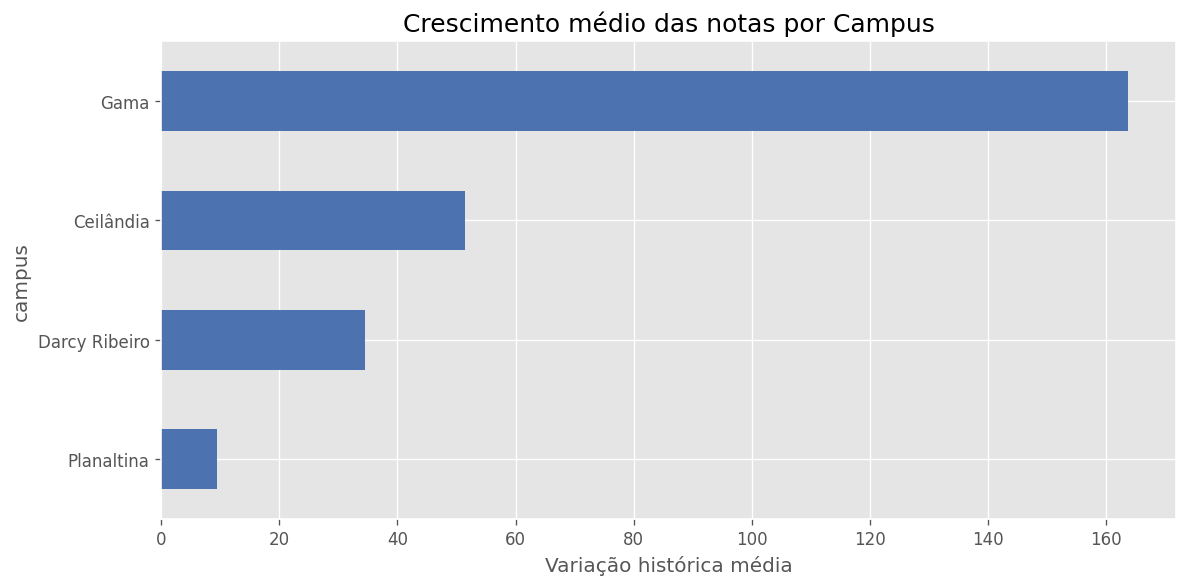

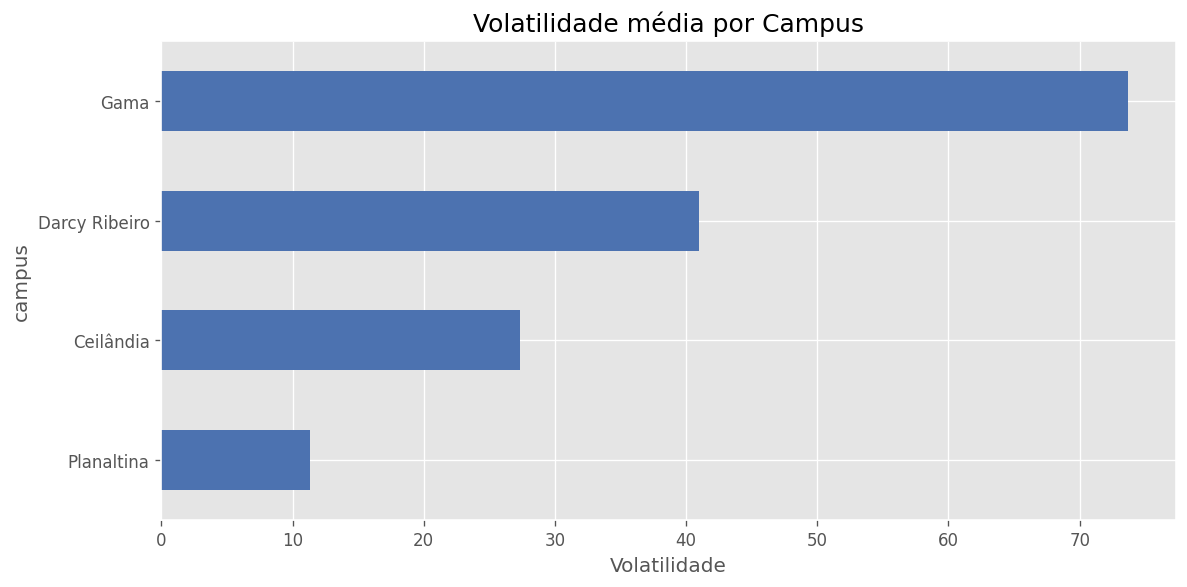

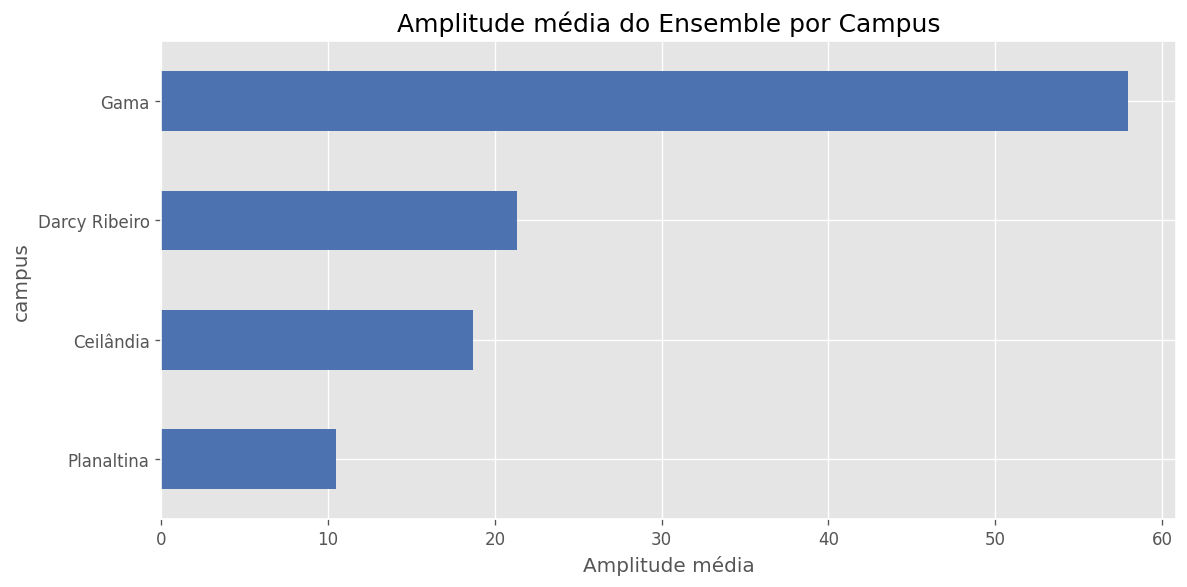

,ofertas,media_nota,crescimento,volatilidade,coef_var,consistencia,amplitude,desvio_ensemble,amplitude_ensemble
ofertas,1.000000,0.148185,-0.329886,0.030585,-0.023413,-0.718278,-0.202432,-0.202299,-0.220229
media_nota,0.148185,1.000000,0.825340,0.920247,0.438118,0.136312,0.855789,0.827917,0.828431
crescimento,-0.329886,0.825340,1.000000,0.933131,0.698760,0.669604,0.989717,0.984134,0.988012
volatilidade,0.030585,0.920247,0.933131,1.000000,0.749442,0.450380,0.972203,0.968127,0.965012
coef_var,-0.023413,0.438118,0.698760,0.749442,1.000000,0.708736,0.758852,0.798611,0.787311
consistencia,-0.718278,0.136312,0.669604,0.450380,0.708736,1.000000,0.623035,0.654122,0.658217
amplitude,-0.202432,0.855789,0.989717,0.972203,0.758852,0.623035,1.000000,0.997889,0.998569
desvio_ensemble,-0.202299,0.827917,0.984134,0.968127,0.798611,0.654122,0.997889,1.000000,0.999726
amplitude_ensemble,-0.220229,0.828431,0.988012,0.965012,0.787311,0.658217,0.998569,0.999726,1.000000


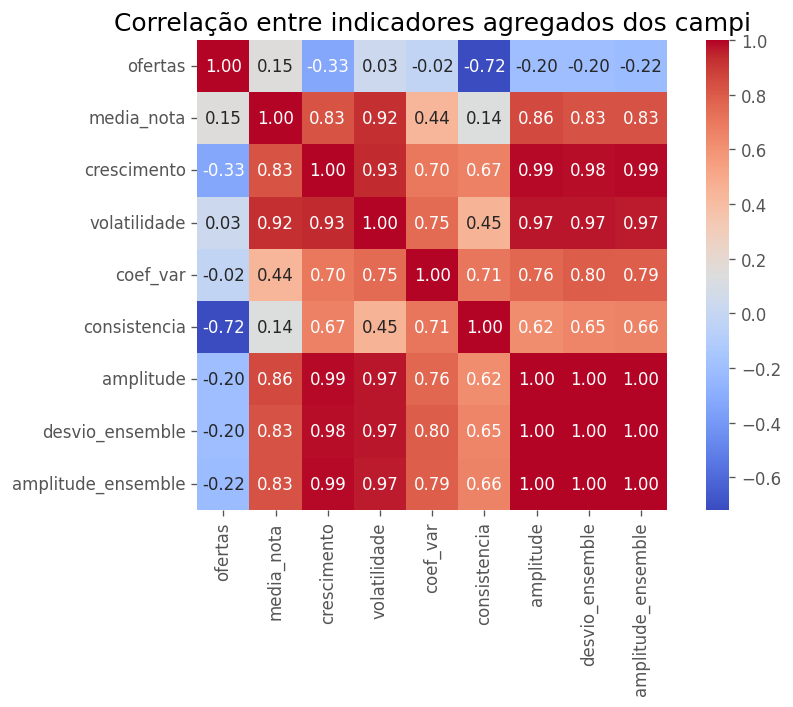

In [26]:
# ==============================================================================
# 17. INTELIGÊNCIA ANALÍTICA POR CAMPUS
# ==============================================================================

print("=" * 80)
print("INTELIGÊNCIA ANALÍTICA POR CAMPUS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

# ------------------------------------------------------------------------------
# Crescimento histórico
# ------------------------------------------------------------------------------

ac["variacao_historica"] = (
    ac["ultima_nota_min"] -
    ac["primeira_nota_min"]
)

# ==============================================================================
# PAINEL DOS CAMPI
# ==============================================================================

painel_campus = (

    ac

    .groupby("campus")

    .agg(

        ofertas=("id_oferta", "count"),

        media_nota=("media_historica_min", "mean"),

        crescimento=("variacao_historica", "mean"),

        volatilidade=("volatilidade_min", "mean"),

        coef_var=("coef_var_min", "mean"),

        consistencia=("consistencia_min", "mean"),

        amplitude=("amplitude_historica_min", "mean"),

        desvio_ensemble=("ensemble_desvio_min", "mean"),

        amplitude_ensemble=("ensemble_amplitude_min", "mean")

    )

    .round(2)

    .sort_values(
        "media_nota",
        ascending=False
    )

)

display(painel_campus)

# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(12,5))

sns.heatmap(

    painel_campus,

    annot=True,

    fmt=".2f",

    cmap="YlGnBu"

)

plt.title("Indicadores médios por Campus")

plt.tight_layout()

plt.show()

# ==============================================================================
# RANKING DAS NOTAS HISTÓRICAS
# ==============================================================================

plt.figure(figsize=(10,5))

painel_campus["media_nota"].sort_values().plot.barh()

plt.title("Nota histórica média por Campus")

plt.xlabel("Nota média")

plt.tight_layout()

plt.show()

# ==============================================================================
# RANKING DO CRESCIMENTO
# ==============================================================================

plt.figure(figsize=(10,5))

painel_campus["crescimento"].sort_values().plot.barh()

plt.title("Crescimento médio das notas por Campus")

plt.xlabel("Variação histórica média")

plt.tight_layout()

plt.show()

# ==============================================================================
# RANKING DA VOLATILIDADE
# ==============================================================================

plt.figure(figsize=(10,5))

painel_campus["volatilidade"].sort_values().plot.barh()

plt.title("Volatilidade média por Campus")

plt.xlabel("Volatilidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# RANKING DA PREVISIBILIDADE
# ==============================================================================

plt.figure(figsize=(10,5))

painel_campus["amplitude_ensemble"].sort_values().plot.barh()

plt.title("Amplitude média do Ensemble por Campus")

plt.xlabel("Amplitude média")

plt.tight_layout()

plt.show()

# ==============================================================================
# CORRELAÇÃO ENTRE INDICADORES DOS CAMPI
# ==============================================================================

corr = painel_campus.corr(numeric_only=True)

display(corr)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlação entre indicadores agregados dos campi")

plt.tight_layout()

plt.show()

# Seção 11 - Inteligência Comparativa entre Modalidades

INTELIGÊNCIA COMPARATIVA ENTRE MODALIDADES


,ofertas,media_nota,crescimento,volatilidade,coef_var,consistencia,amplitude,desvio_ensemble,amplitude_ensemble
modalidade,,,,,,,,,
AC,105,-7.43,35.70,39.38,-5.73,66.98,61.95,9.51,21.11
CN,91,-1.71,12.04,35.98,10.44,72.89,57.04,11.38,24.77
EP_R1_NPPI,87,-23.68,0.32,27.42,-69.10,76.82,40.45,9.88,21.25
EP_R1_NPPIQ,41,-34.07,0.00,0.00,0.00,100.00,0.00,0.00,0.00
EP_R1_NPPIQ_PCD,1,46.78,0.00,0.00,0.00,100.00,0.00,0.00,0.00
EP_R1_NPPI_PCD,3,-9.24,0.00,0.00,0.00,100.00,0.00,0.00,0.00
EP_R1_PPI,85,-30.22,11.58,21.80,-54.01,82.14,38.10,10.60,22.58
EP_R1_PPIQ,9,-30.88,0.00,0.00,0.00,100.00,0.00,0.00,0.00
EP_R1_PPI_PCD,2,-19.22,16.67,0.00,-50.46,100.00,16.67,11.45,22.22


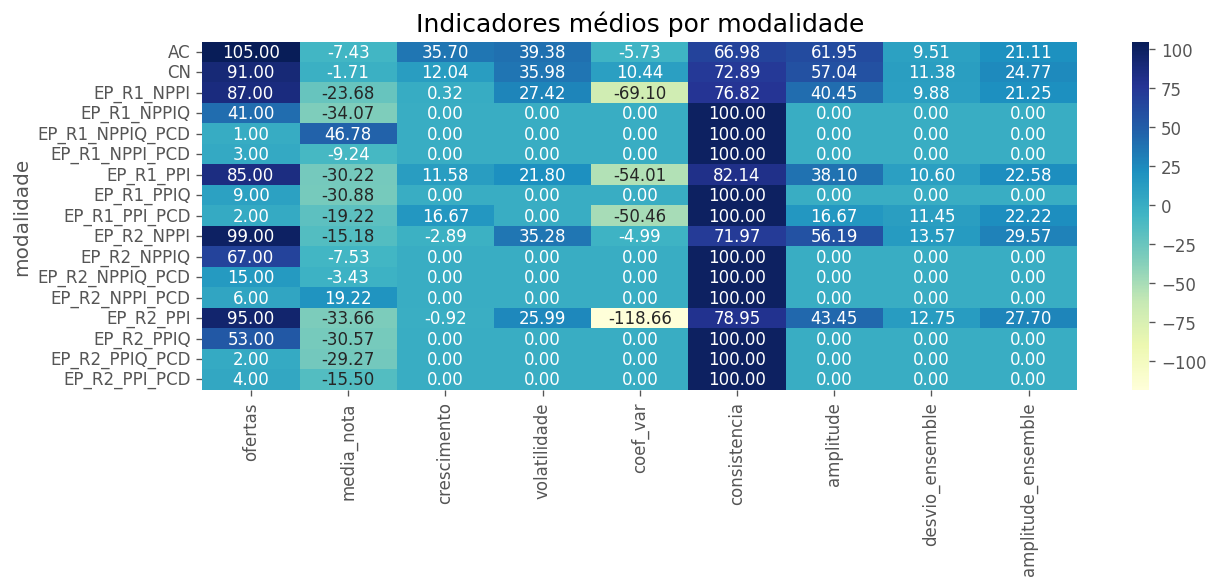

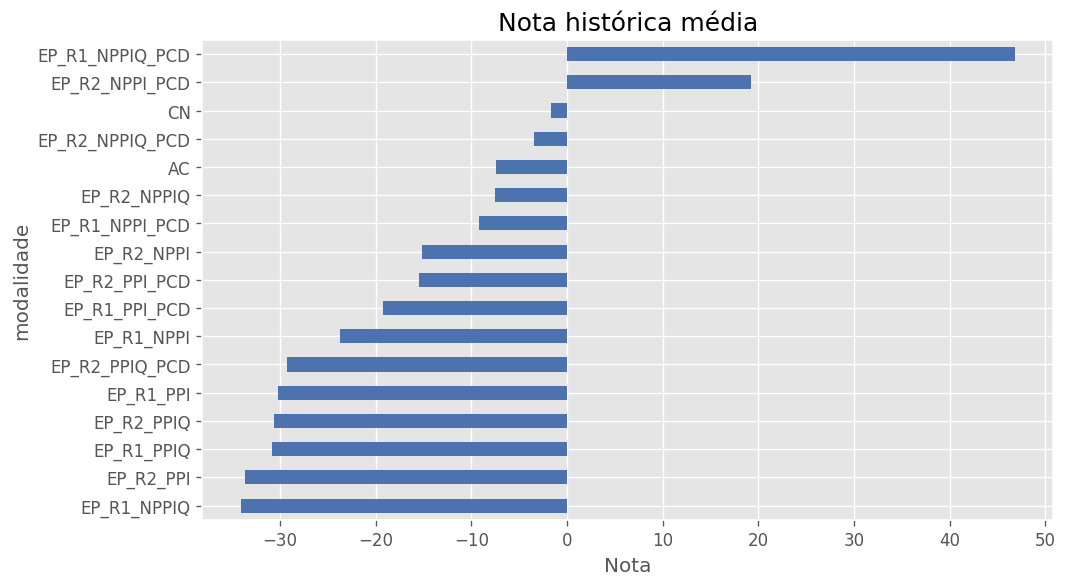

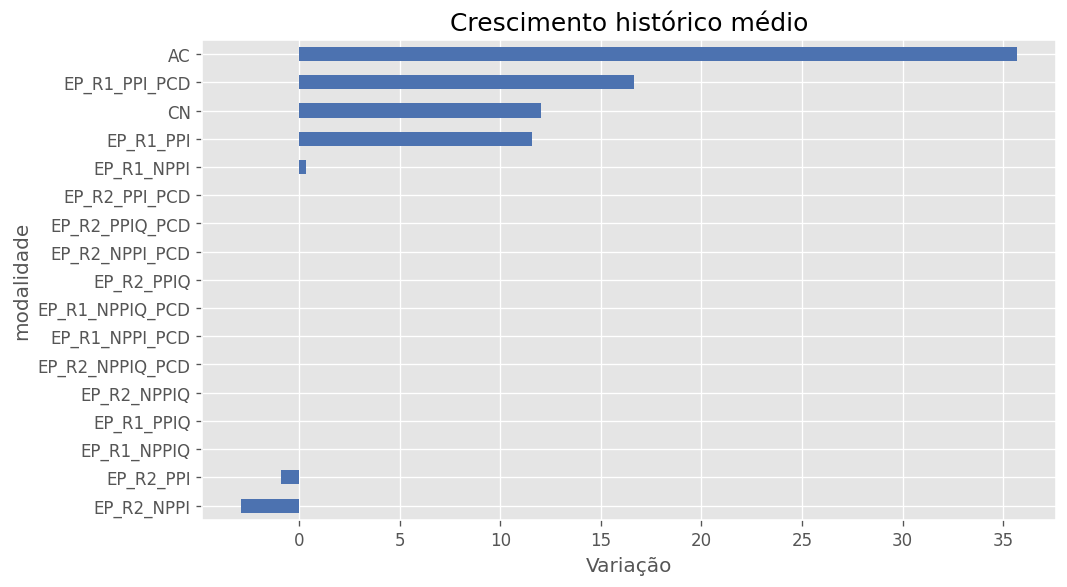

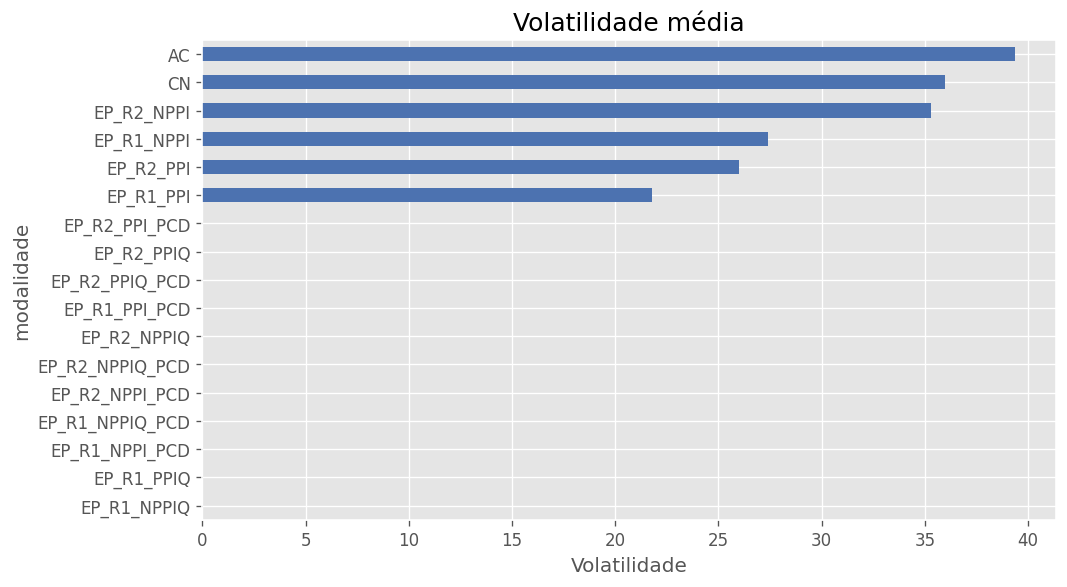

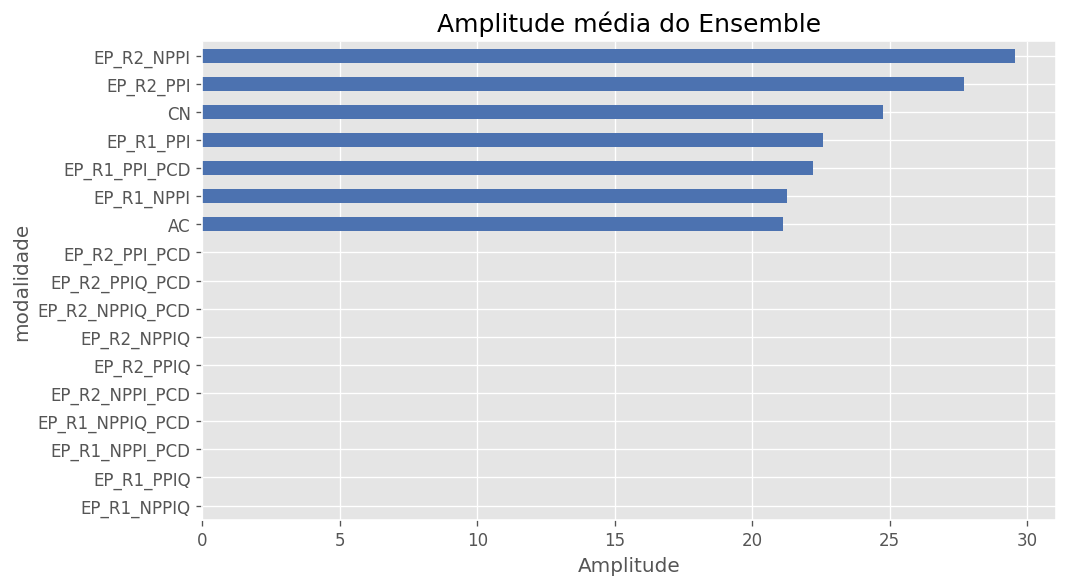

,ofertas,media_nota,crescimento,volatilidade,coef_var,consistencia,amplitude,desvio_ensemble,amplitude_ensemble
ofertas,1.000000,-0.283081,0.345028,0.880255,-0.384867,-0.882198,0.854604,0.725234,0.750534
media_nota,-0.283081,1.000000,0.022138,-0.114112,0.378001,0.121322,-0.136814,-0.229219,-0.225783
crescimento,0.345028,0.022138,1.000000,0.479836,-0.036005,-0.491926,0.541907,0.445458,0.440968
volatilidade,0.880255,-0.114112,0.479836,1.000000,-0.339998,-0.998717,0.985676,0.842180,0.866347
coef_var,-0.384867,0.378001,-0.036005,-0.339998,1.000000,0.356250,-0.399466,-0.613653,-0.604906
consistencia,-0.882198,0.121322,-0.491926,-0.998717,0.356250,1.000000,-0.983779,-0.839027,-0.863191
amplitude,0.854604,-0.136814,0.541907,0.985676,-0.399466,-0.983779,1.000000,0.912552,0.929270
desvio_ensemble,0.725234,-0.229219,0.445458,0.842180,-0.613653,-0.839027,0.912552,1.000000,0.998698
amplitude_ensemble,0.750534,-0.225783,0.440968,0.866347,-0.604906,-0.863191,0.929270,0.998698,1.000000


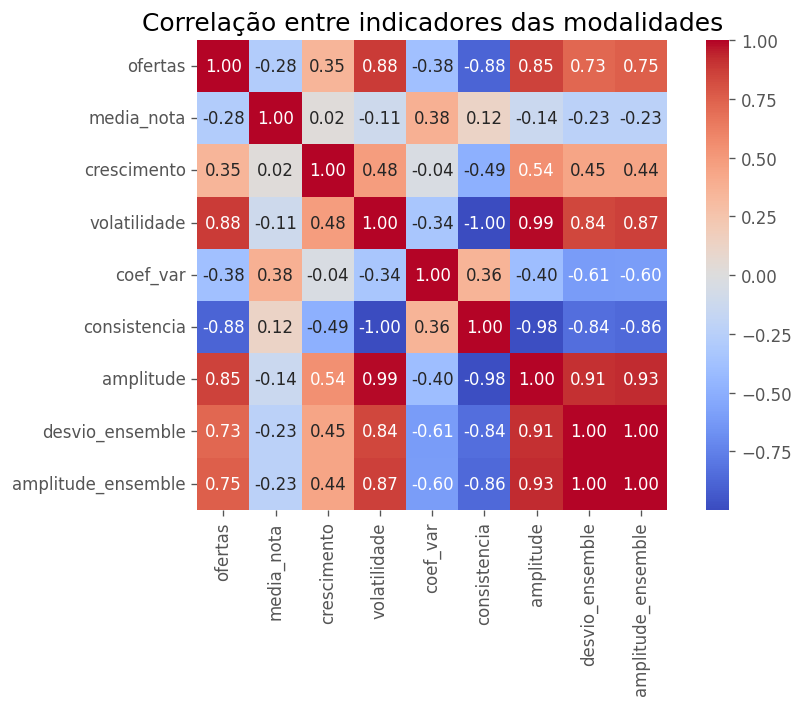

In [27]:
# ==============================================================================
# 18. INTELIGÊNCIA COMPARATIVA ENTRE MODALIDADES
# ==============================================================================

print("=" * 80)
print("INTELIGÊNCIA COMPARATIVA ENTRE MODALIDADES")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base completa
# ------------------------------------------------------------------------------

modalidades = predicoes.copy()

# ------------------------------------------------------------------------------
# Crescimento histórico
# ------------------------------------------------------------------------------

modalidades["variacao_historica"] = (
    modalidades["ultima_nota_min"] -
    modalidades["primeira_nota_min"]
)

# ==============================================================================
# PAINEL DAS MODALIDADES
# ==============================================================================

painel_modalidade = (

    modalidades

    .groupby("modalidade")

    .agg(

        ofertas=("id_oferta", "count"),

        media_nota=("media_historica_min", "mean"),

        crescimento=("variacao_historica", "mean"),

        volatilidade=("volatilidade_min", "mean"),

        coef_var=("coef_var_min", "mean"),

        consistencia=("consistencia_min", "mean"),

        amplitude=("amplitude_historica_min", "mean"),

        desvio_ensemble=("ensemble_desvio_min", "mean"),

        amplitude_ensemble=("ensemble_amplitude_min", "mean")

    )

    .round(2)

)

display(painel_modalidade)

# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(11,5))

sns.heatmap(

    painel_modalidade,

    annot=True,

    fmt=".2f",

    cmap="YlGnBu"

)

plt.title("Indicadores médios por modalidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# MÉDIA HISTÓRICA
# ==============================================================================

plt.figure(figsize=(9,5))

painel_modalidade["media_nota"].sort_values().plot.barh()

plt.title("Nota histórica média")

plt.xlabel("Nota")

plt.tight_layout()

plt.show()

# ==============================================================================
# CRESCIMENTO
# ==============================================================================

plt.figure(figsize=(9,5))

painel_modalidade["crescimento"].sort_values().plot.barh()

plt.title("Crescimento histórico médio")

plt.xlabel("Variação")

plt.tight_layout()

plt.show()

# ==============================================================================
# VOLATILIDADE
# ==============================================================================

plt.figure(figsize=(9,5))

painel_modalidade["volatilidade"].sort_values().plot.barh()

plt.title("Volatilidade média")

plt.xlabel("Volatilidade")

plt.tight_layout()

plt.show()

# ==============================================================================
# PREVISIBILIDADE
# ==============================================================================

plt.figure(figsize=(9,5))

painel_modalidade["amplitude_ensemble"].sort_values().plot.barh()

plt.title("Amplitude média do Ensemble")

plt.xlabel("Amplitude")

plt.tight_layout()

plt.show()

# ==============================================================================
# CORRELAÇÃO
# ==============================================================================

corr = painel_modalidade.corr(numeric_only=True)

display(corr)

plt.figure(figsize=(8,6))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f",

    square=True

)

plt.title("Correlação entre indicadores das modalidades")

plt.tight_layout()

plt.show()

# Seção 12 - Convergência das Modalidades em Relação à Ampla Concorrência

CONVERGÊNCIA DAS MODALIDADES EM RELAÇÃO À AC
Comparações realizadas: 659

RESUMO DAS MODALIDADES



,ofertas,diferenca_media,diferenca_media_absoluta,diferenca_percentual,diferenca_volatilidade,diferenca_consistencia,diferenca_ensemble
modalidade,,,,,,,
EP_R2_NPPIQ,67,-22.20,26.04,-12.28,-46.01,35.22,-32.89
CN,91,0.40,26.81,-42.27,-6.34,7.25,-4.67
EP_R2_NPPI,98,-10.39,28.01,-68.20,-5.59,5.95,-25.35
EP_R2_PPI,95,-29.22,43.69,-98.60,-14.59,13.35,-40.81
EP_R1_NPPI,87,-23.96,44.60,-95.27,-15.30,11.82,-34.75
EP_R1_PPI,85,-30.45,45.32,-115.93,-20.22,17.40,-33.82
EP_R2_NPPIQ_PCD,15,-55.10,56.62,-11.56,-34.17,35.00,-64.98
EP_R2_PPIQ,53,-61.03,61.17,-8.33,-47.26,35.85,-73.90
EP_R2_PPI_PCD,4,-30.96,70.15,-90.20,-37.63,33.75,-27.89


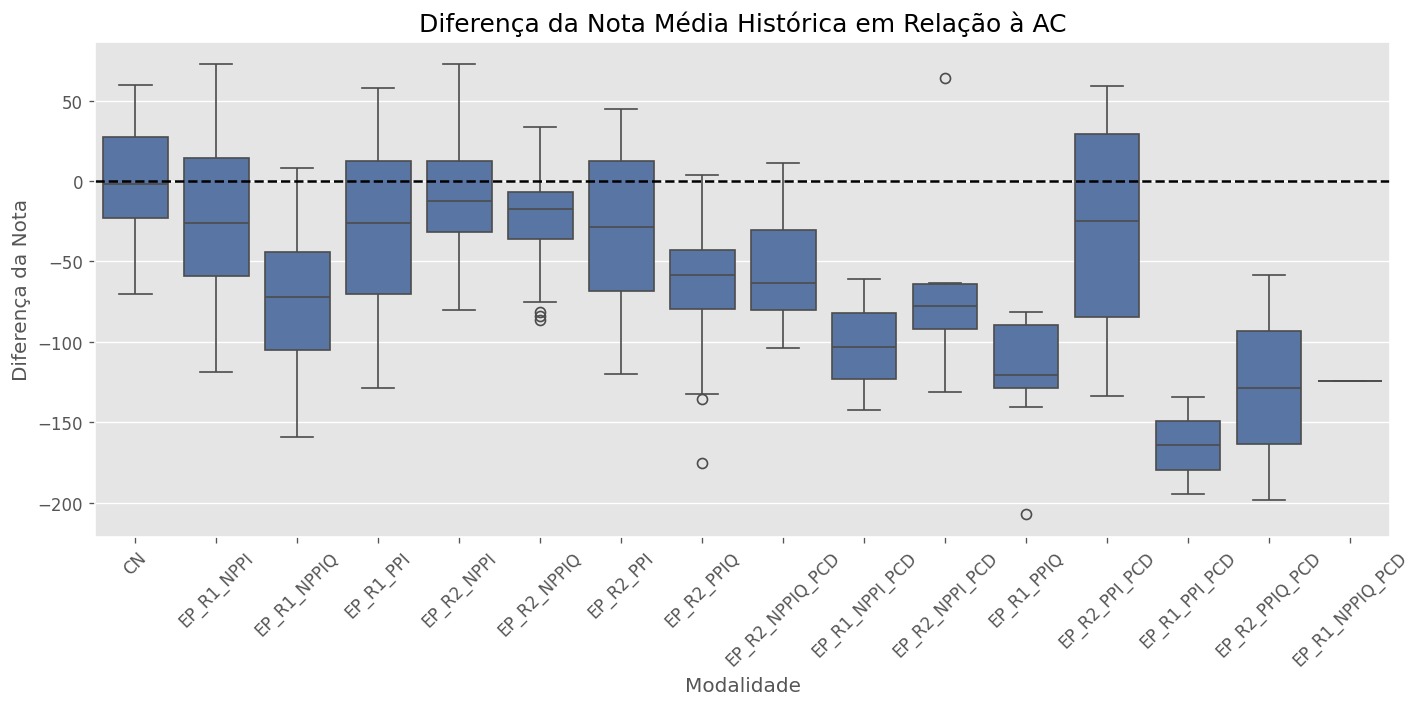


20 OFERTAS MAIS PRÓXIMAS DA AC



,curso,campus,turno,modalidade,media_historica_min,media_ac,dif_media
634,Museologia (Bacharelado),Darcy Ribeiro,Diurno,EP_R2_PPI,-63.640,-63.708,0.068
567,Letras – Português do Brasil como Segunda Língua (Licenciatura),Darcy Ribeiro,Diurno,EP_R1_PPI,-46.700,-46.602,-0.098
569,Letras – Português do Brasil como Segunda Língua (Licenciatura),Darcy Ribeiro,Diurno,EP_R2_PPI,-46.859,-46.602,-0.257
63,Artes Cênicas (Literatura),Darcy Ribeiro,Noturno,EP_R2_NPPI,-68.553,-68.863,0.310
62,Artes Cênicas (Literatura),Darcy Ribeiro,Diurno,EP_R2_NPPI,-21.566,-20.971,-0.595
572,Letras – Tradução – Espanhol (Bacharelado),Darcy Ribeiro,Noturno,EP_R2_NPPI,-57.502,-58.181,0.679
602,Matemática (Licenciatura),Darcy Ribeiro,Noturno,EP_R2_NPPI,-54.593,-53.891,-0.702
8,Administração (Bacharelado),Darcy Ribeiro,Noturno,EP_R1_PPI,-38.741,-38.006,-0.735
594,Matemática (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,EP_R1_PPI,-17.430,-18.201,0.771
177,Ciências Sociais – Antropologia/ Sociologia (Bacharelado/Licenciatura),Darcy Ribeiro,Diurno,CN,-17.392,-16.418,-0.974



20 OFERTAS MAIS DISTANTES DA AC



,curso,campus,turno,modalidade,media_historica_min,media_ac,dif_media
237,Direito (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_PPIQ,-87.773,119.530,-207.303
618,Medicina (Bacharelado),Darcy Ribeiro,Diurno,EP_R2_PPIQ_PCD,-27.585,171.083,-198.668
611,Medicina (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_PPI_PCD,-23.356,171.083,-194.439
352,Engenharia de Computação (Bacharelado),Darcy Ribeiro,Diurno,EP_R2_PPIQ,-67.012,108.165,-175.177
129,Ciência da Computação (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPIQ,-38.263,120.698,-158.961
711,Relações Internacionais (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPIQ,-59.284,88.904,-148.188
86,Biologia (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPIQ,-78.848,67.391,-146.239
234,Direito (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPI_PCD,-22.954,119.530,-142.484
346,Engenharia de Computação (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_NPPIQ,-33.752,108.165,-141.917
655,Odontologia (Bacharelado),Darcy Ribeiro,Diurno,EP_R1_PPIQ,-62.296,78.348,-140.644


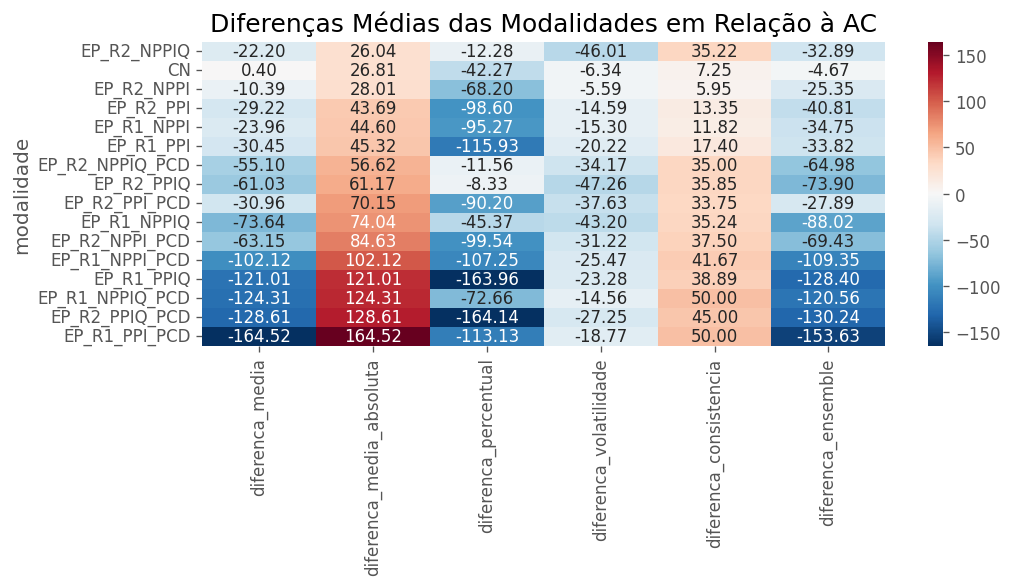

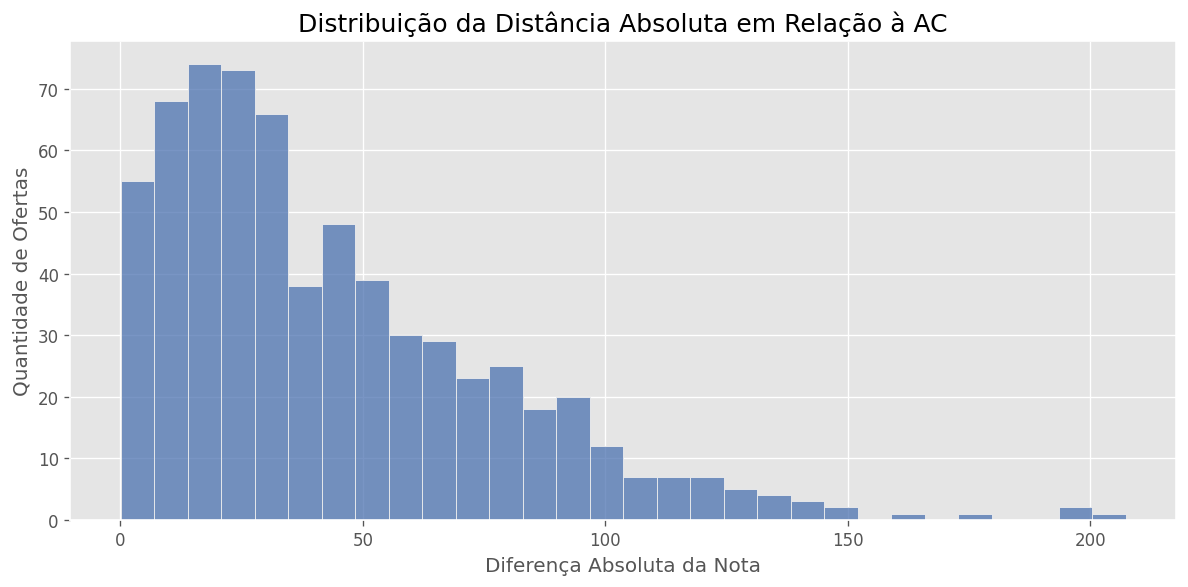


RANKING DE PROXIMIDADE EM RELAÇÃO À AC



,diferenca_media_absoluta
modalidade,
EP_R2_NPPIQ,26.04
CN,26.81
EP_R2_NPPI,28.01
EP_R2_PPI,43.69
EP_R1_NPPI,44.60
EP_R1_PPI,45.32
EP_R2_NPPIQ_PCD,56.62
EP_R2_PPIQ,61.17
EP_R2_PPI_PCD,70.15


In [29]:
# ==============================================================================
# 19. CONVERGÊNCIA DAS MODALIDADES EM RELAÇÃO À AMPLA CONCORRÊNCIA
# ==============================================================================

print("=" * 80)
print("CONVERGÊNCIA DAS MODALIDADES EM RELAÇÃO À AC")
print("=" * 80)

# ==============================================================================
# BASE DA AMPLA CONCORRÊNCIA
# ==============================================================================

ac = (

    predicoes

    .loc[
        predicoes["modalidade"] == "AC",

        [
            "curso",
            "campus",
            "turno",

            "media_historica_min",
            "mediana_historica_min",

            "volatilidade_min",
            "consistencia_min",

            "ensemble_min"
        ]

    ]

    .rename(columns={

        "media_historica_min": "media_ac",
        "mediana_historica_min": "mediana_ac",

        "volatilidade_min": "volatilidade_ac",
        "consistencia_min": "consistencia_ac",

        "ensemble_min": "ensemble_ac"

    })

)

# ==============================================================================
# JUNÇÃO COM TODAS AS MODALIDADES
# ==============================================================================

comparacao = (

    predicoes

    .merge(

        ac,

        on=[
            "curso",
            "campus",
            "turno"
        ],

        how="inner"

    )

)

# Remove a própria AC

comparacao = (

    comparacao

    .loc[
        comparacao["modalidade"] != "AC"
    ]

    .copy()

)

print(f"Comparações realizadas: {len(comparacao):,}")

# ==============================================================================
# DIFERENÇAS EM RELAÇÃO À AC
# ==============================================================================

comparacao["dif_media"] = (

    comparacao["media_historica_min"]

    - comparacao["media_ac"]

)

comparacao["dif_media_abs"] = (

    comparacao["dif_media"].abs()

)

comparacao["dif_percentual"] = (

    100 *

    comparacao["dif_media"]

    / comparacao["media_ac"]

)

comparacao["dif_volatilidade"] = (

    comparacao["volatilidade_min"]

    - comparacao["volatilidade_ac"]

)

comparacao["dif_consistencia"] = (

    comparacao["consistencia_min"]

    - comparacao["consistencia_ac"]

)

comparacao["dif_ensemble"] = (

    comparacao["ensemble_min"]

    - comparacao["ensemble_ac"]

)

# ==============================================================================
# RESUMO DAS MODALIDADES
# ==============================================================================

resumo = (

    comparacao

    .groupby("modalidade")

    .agg(

        ofertas=("curso","count"),

        diferenca_media=("dif_media","mean"),

        diferenca_media_absoluta=("dif_media_abs","mean"),

        diferenca_percentual=("dif_percentual","mean"),

        diferenca_volatilidade=("dif_volatilidade","mean"),

        diferenca_consistencia=("dif_consistencia","mean"),

        diferenca_ensemble=("dif_ensemble","mean")

    )

    .round(2)

    .sort_values(
        "diferenca_media_absoluta"
    )

)

print("\nRESUMO DAS MODALIDADES\n")

display(resumo)

# ==============================================================================
# BOXPLOT DAS DIFERENÇAS
# ==============================================================================

plt.figure(figsize=(12,6))

sns.boxplot(

    data=comparacao,

    x="modalidade",

    y="dif_media"

)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Diferença da Nota Média Histórica em Relação à AC")

plt.xlabel("Modalidade")

plt.ylabel("Diferença da Nota")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==============================================================================
# MAIORES CONVERGÊNCIAS
# ==============================================================================

print("\n20 OFERTAS MAIS PRÓXIMAS DA AC\n")

display(

    comparacao

    .sort_values("dif_media_abs")

    [[

        "curso",

        "campus",

        "turno",

        "modalidade",

        "media_historica_min",

        "media_ac",

        "dif_media"

    ]]

    .head(20)

)

# ==============================================================================
# MAIORES DIVERGÊNCIAS
# ==============================================================================

print("\n20 OFERTAS MAIS DISTANTES DA AC\n")

display(

    comparacao

    .sort_values(
        "dif_media_abs",
        ascending=False
    )

    [[

        "curso",

        "campus",

        "turno",

        "modalidade",

        "media_historica_min",

        "media_ac",

        "dif_media"

    ]]

    .head(20)

)

# ==============================================================================
# HEATMAP DOS INDICADORES
# ==============================================================================

plt.figure(figsize=(9,5))

sns.heatmap(

    resumo[

        [

            "diferenca_media",

            "diferenca_media_absoluta",

            "diferenca_percentual",

            "diferenca_volatilidade",

            "diferenca_consistencia",

            "diferenca_ensemble"

        ]

    ],

    annot=True,

    fmt=".2f",

    cmap="RdBu_r",

    center=0

)

plt.title("Diferenças Médias das Modalidades em Relação à AC")

plt.tight_layout()

plt.show()

# ==============================================================================
# DISTRIBUIÇÃO DAS DISTÂNCIAS PARA A AC
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(

    data=comparacao,

    x="dif_media_abs",

    bins=30

)

plt.title("Distribuição da Distância Absoluta em Relação à AC")

plt.xlabel("Diferença Absoluta da Nota")

plt.ylabel("Quantidade de Ofertas")

plt.tight_layout()

plt.show()

# ==============================================================================
# RANKING DAS MODALIDADES MAIS PRÓXIMAS DA AC
# ==============================================================================

ranking = (

    resumo

    [["diferenca_media_absoluta"]]

    .sort_values("diferenca_media_absoluta")

)

print("\nRANKING DE PROXIMIDADE EM RELAÇÃO À AC\n")

display(ranking)

# Seção 13 - Relações Estruturais entre os Indicadores

RELAÇÕES ESTRUTURAIS ENTRE OS INDICADORES

Matriz de Correlação



,media_historica_min,amplitude_historica_min,desvio_historico_min,coef_var_min,consistencia_min,volatilidade_min,variacao_historica,ensemble_min,ensemble_desvio_min,ensemble_amplitude_min
media_historica_min,1.000,0.083,0.069,0.118,-0.097,0.075,0.273,0.964,-0.116,-0.101
amplitude_historica_min,0.083,1.000,0.983,-0.043,-0.281,0.920,0.718,0.183,0.750,0.766
desvio_historico_min,0.069,0.983,1.000,-0.045,-0.252,0.942,0.729,0.176,0.773,0.780
coef_var_min,0.118,-0.043,-0.045,1.000,0.219,-0.057,0.025,0.122,-0.073,-0.076
consistencia_min,-0.097,-0.281,-0.252,0.219,1.000,-0.350,-0.120,-0.085,-0.037,-0.053
volatilidade_min,0.075,0.920,0.942,-0.057,-0.350,1.000,0.617,0.150,0.602,0.612
variacao_historica,0.273,0.718,0.729,0.025,-0.120,0.617,1.000,0.472,0.519,0.532
ensemble_min,0.964,0.183,0.176,0.122,-0.085,0.150,0.472,1.000,-0.004,0.011
ensemble_desvio_min,-0.116,0.750,0.773,-0.073,-0.037,0.602,0.519,-0.004,1.000,0.996
ensemble_amplitude_min,-0.101,0.766,0.780,-0.076,-0.053,0.612,0.532,0.011,0.996,1.000


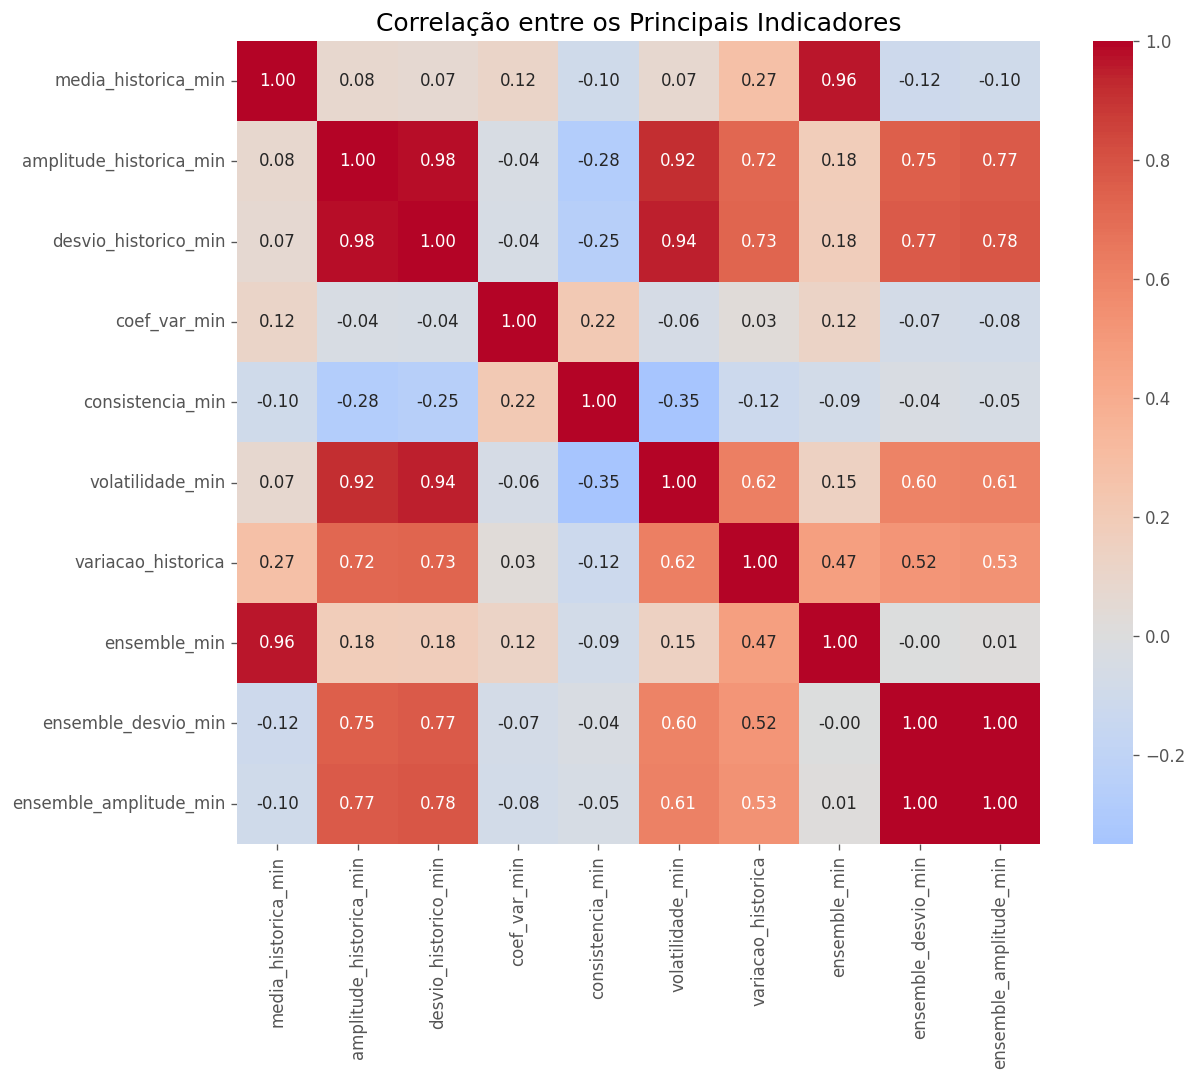


20 MAIORES CORRELAÇÕES



,Indicador_1,Indicador_2,Correlacao,Abs
89,ensemble_desvio_min,ensemble_amplitude_min,0.996,0.996
12,amplitude_historica_min,desvio_historico_min,0.983,0.983
7,media_historica_min,ensemble_min,0.964,0.964
25,desvio_historico_min,volatilidade_min,0.942,0.942
15,amplitude_historica_min,volatilidade_min,0.920,0.920
29,desvio_historico_min,ensemble_amplitude_min,0.780,0.780
28,desvio_historico_min,ensemble_desvio_min,0.773,0.773
19,amplitude_historica_min,ensemble_amplitude_min,0.766,0.766
18,amplitude_historica_min,ensemble_desvio_min,0.750,0.750
26,desvio_historico_min,variacao_historica,0.729,0.729


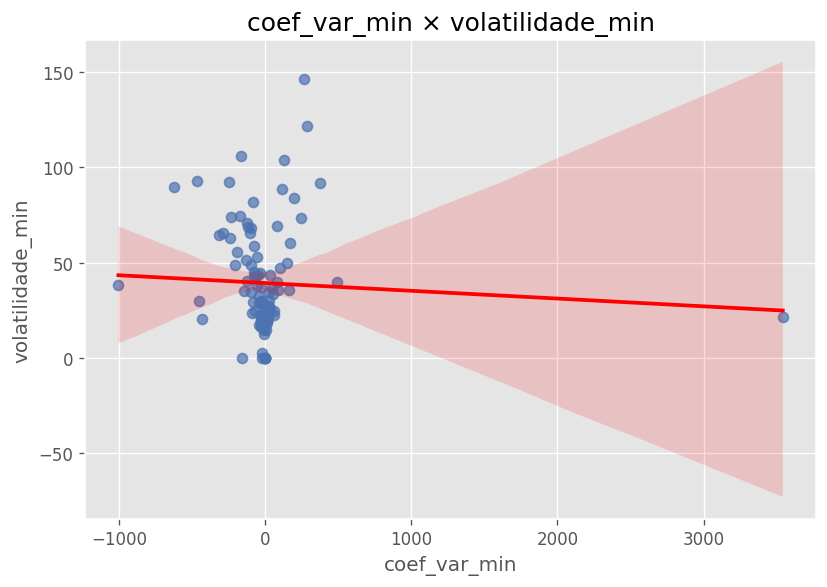

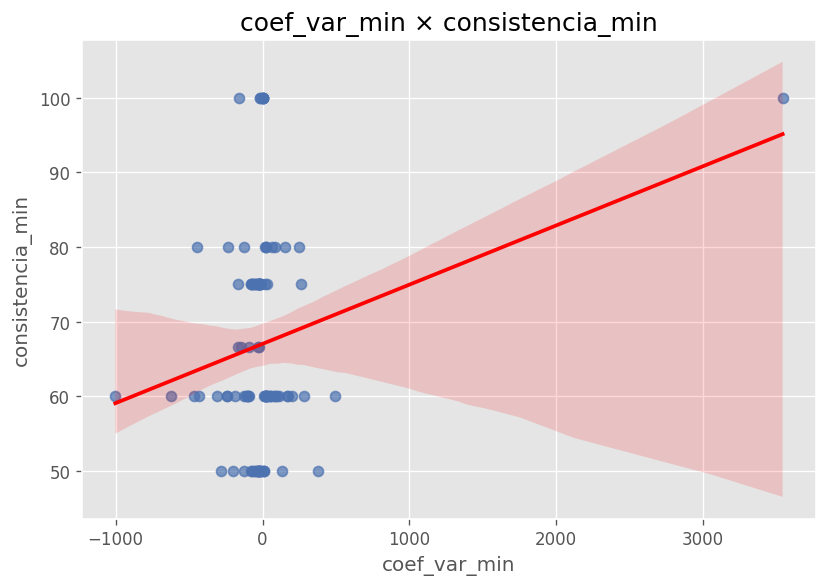

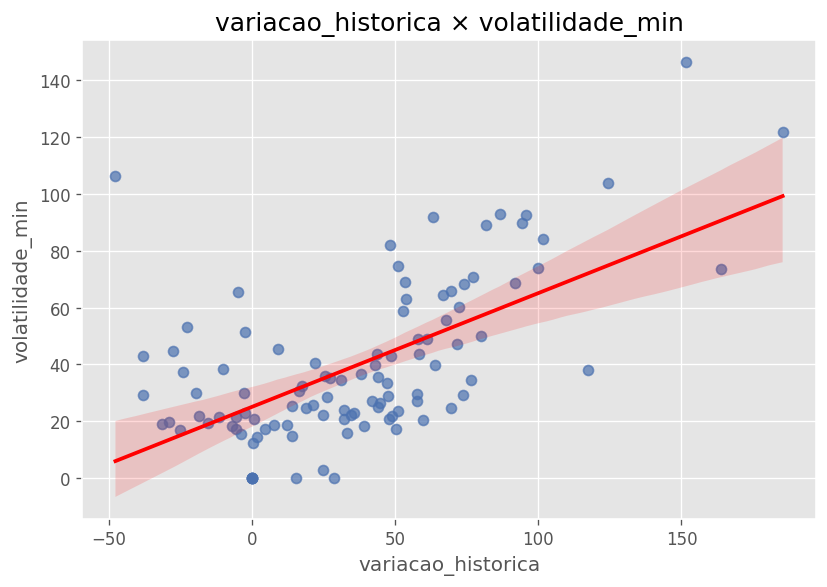

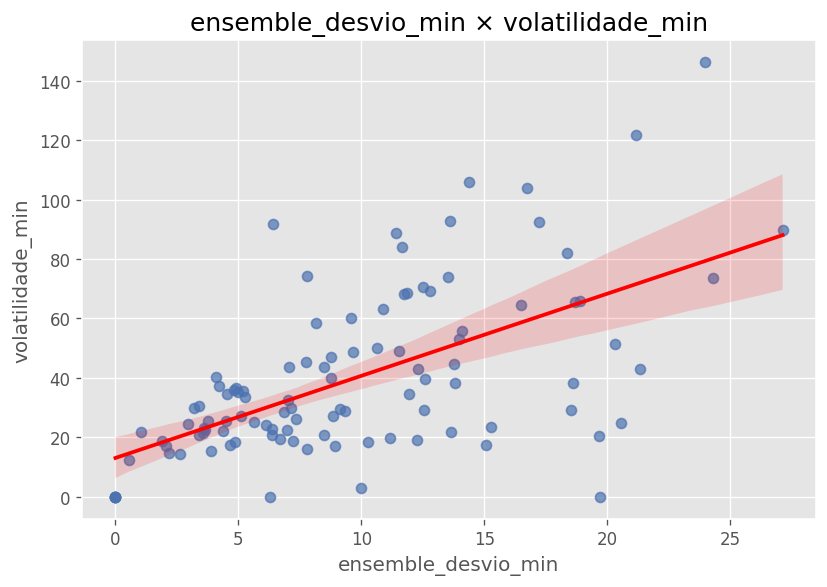

In [30]:
# ==============================================================================
# 20. RELAÇÕES ESTRUTURAIS ENTRE OS INDICADORES
# ==============================================================================

print("=" * 80)
print("RELAÇÕES ESTRUTURAIS ENTRE OS INDICADORES")
print("=" * 80)

# ------------------------------------------------------------------------------
# Base AC
# ------------------------------------------------------------------------------

ac = predicoes.loc[
    predicoes["modalidade"] == "AC"
].copy()

ac["variacao_historica"] = (
    ac["ultima_nota_min"] -
    ac["primeira_nota_min"]
)

# ==============================================================================
# VARIÁVEIS ANALISADAS
# ==============================================================================

variaveis = [

    "media_historica_min",
    "amplitude_historica_min",
    "desvio_historico_min",
    "coef_var_min",
    "consistencia_min",
    "volatilidade_min",
    "variacao_historica",
    "ensemble_min",
    "ensemble_desvio_min",
    "ensemble_amplitude_min"

]

# ==============================================================================
# MATRIZ DE CORRELAÇÃO
# ==============================================================================

correlacao = (
    ac[variaveis]
    .corr(method="pearson")
    .round(3)
)

print("\nMatriz de Correlação\n")
display(correlacao)

plt.figure(figsize=(11,9))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("Correlação entre os Principais Indicadores")

plt.tight_layout()

plt.show()

# ==============================================================================
# CORRELAÇÕES MAIS FORTES
# ==============================================================================

corr_long = (

    correlacao

    .stack()

    .reset_index()

)

corr_long.columns = [

    "Indicador_1",
    "Indicador_2",
    "Correlacao"

]

# Remove diagonal
corr_long = corr_long[
    corr_long["Indicador_1"] != corr_long["Indicador_2"]
]

# Remove duplicidades
corr_long["Par"] = corr_long.apply(
    lambda x: tuple(sorted([x["Indicador_1"], x["Indicador_2"]])),
    axis=1
)

corr_long = (
    corr_long
    .drop_duplicates("Par")
    .drop(columns="Par")
)

corr_long["Abs"] = corr_long["Correlacao"].abs()

corr_long = corr_long.sort_values(
    "Abs",
    ascending=False
)

print("\n20 MAIORES CORRELAÇÕES\n")

display(
    corr_long.head(20)
)

# ==============================================================================
# DISPERSÕES MAIS IMPORTANTES
# ==============================================================================

pares = [

    ("coef_var_min", "volatilidade_min"),
    ("coef_var_min", "consistencia_min"),
    ("variacao_historica", "volatilidade_min"),
    ("ensemble_desvio_min", "volatilidade_min")

]

for x, y in pares:

    plt.figure(figsize=(7,5))

    sns.regplot(
        data=ac,
        x=x,
        y=y,
        scatter_kws={"alpha":0.7},
        line_kws={"color":"red"}
    )

    plt.title(f"{x} × {y}")

    plt.tight_layout()

    plt.show()

# Selão 14